#Trabajo Final — Agricultura Predictiva
## Predicción del rendimiento foliar de cultivos colombianos mediante Machine Learning

**Fuente de datos:** Análisis Vegetal (Foliar) — AGROSAVIA 2018–2024  
**Integrantes:** Paola Restrepo · Sofía Vásquez  
**Universidad EAFIT · 2026**

---

##Planteamiento del problema

Colombia enfrenta pérdidas agrícolas significativas causadas por deficiencias nutricionales en los cultivos que no son detectadas a tiempo. El **análisis foliar**, medir la concentración de nutrientes en las hojas de las plantas es una herramienta de diagnóstico que permite conocer el estado nutricional de un cultivo antes de que el daño sea irreversible.

**AGROSAVIA** (Corporación Colombiana de Investigación Agropecuaria) registra estos análisis en una base de datos nacional con más de **10.000 muestras foliares** de **171 cultivos** en **26 departamentos** del país.


**Pregunta de investigación:**
> ¿Es posible predecir si el rendimiento de un cultivo colombiano será **bueno, regular o malo** a partir de sus nutrientes foliares(N, P, K, Ca, Mg, Na, S, Fe, Cu, Mn, Zn, B) y variables agronómicas?

**Objetivo general:** Desarrollar y comparar modelos de Machine Learning supervisados y no supervisados para predecir el rendimiento agrícola foliar colombiano.

**Justificación:** Un modelo predictivo permitiría a técnicos agrícolas intervenir preventivamente, optimizando fertilización antes de que el cultivo se deteriore, con impacto en la productividad del sector agropecuario colombiano.

##Planteamiento del problema

Colombia enfrenta pérdidas agrícolas significativas causadas por deficiencias nutricionales en los cultivos que no son detectadas a tiempo. El **análisis foliar**, medir la concentración de nutrientes en las hojas de las plantas es una herramienta de diagnóstico que permite conocer el estado nutricional de un cultivo antes de que el daño sea irreversible.

**AGROSAVIA** (Corporación Colombiana de Investigación Agropecuaria) registra estos análisis en una base de datos nacional con más de **10.000 muestras foliares** de **171 cultivos** en **26 departamentos** del país.

###Pregunta de investigación
>

###Objetivo general
Desarrollar y comparar modelos de Machine Learning supervisados y no supervisados para predecir y caracterizar el rendimiento agrícola a partir de datos de análisis foliar.

###Justificación
Un modelo predictivo basado en análisis foliar permitiría a técnicos agrícolas y productores intervenir preventivamente, optimizando la fertilización antes de que el cultivo se deteriore, con impacto directo en la productividad y sostenibilidad del sector agropecuario colombiano.

## 1. Preparación del entorno — Importación de librerías

Importamos todas las librerías necesarias:
- **pandas / numpy**: manipulación de datos
- **matplotlib / seaborn**: visualización
- **sklearn**: modelos de Machine Learning, métricas y preprocesamiento

In [ ]:
import numpy as np #Permite manejar arreglos numéricos de manera eficiente.
import pandas as pd #Sirve para manejar tablas de datos tipo Excel.
import matplotlib.pyplot as plt #Es la librería base para hacer gráficos.
import seaborn as sns #Es una versión más elegante y estadística de Matplotlib.

from sklearn.model_selection import train_test_split, GridSearchCV #Divide los datos en entrenamiento y prueba  y DriedSearchcv busca automáticamente los mejores hiperparámetros de un modelo
from sklearn.preprocessing import StandardScaler, LabelEncoder #Estandariza variables. y Laber convierte texto en números
from sklearn.decomposition import PCA #Reduce variables manteniendo la mayor información posible.
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report) #Respectivamente; metrica para medir correctos / total;balance entre Balance entre: precisión y recall; Crea la matriz de confusión para saber falsos positivos y falsos negativos; finalmente hace un reumen de Accuracy, precision, recall y F1 Score.
from sklearn.linear_model import LogisticRegression # Regresion lINEAL Clasificación binaria o multiclase.
from sklearn.tree import DecisionTreeClassifier # Árbol de decisión.
from sklearn.ensemble import RandomForestClassifier, VotingClassifier #Respectivamente: Combina muchos árboles de decisión y Método de ensamble que Combina varios modelos y votan por la mejor respuesta.
from sklearn.svm import SVC #Support Vector Machine: Máquina de soporte vectorial.
from sklearn.neighbors import KNeighborsClassifier #Clasifica según los vecinos más parecidos.
from sklearn.cluster import KMeans, DBSCAN, MeanShift #Respectivamente: Agrupa datos en K grupo;Agrupa según densidad;Encuentra automáticamente centros de agrupamiento

import warnings
warnings.filterwarnings('ignore') #Permite manejar advertencias del sistema.



## 2. Carga del dataset

Cargamos el archivo Excel de AGROSAVIA desde Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Agricultura Predictiva/Trabajo_Final_Sofía_Paola/Análisis_vegetal_(foliar)_Agrosavia_20260502.xlsx')
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')


Dataset cargado: 10027 filas × 23 columnas


In [ ]:
#Primeras 7 filas
df.head(7)

,No,Fecha de registro,departamento revisado,municipio revisado,Cultivo,Variedad o hibrido,Edad del cultivo (AÑOS),"Parte de la planta a analizar (toda la planta, parte aérea, raíz, tubérculo, tallo, hoja, flor, fruto, semilla)","Sintomatología (tamaño, color, deformación)",Fertilizantes aplicados anteriormente,...,Potasio (K) % STD,Calcio (Ca) % STD,Magnesio (Mg) % STD,Sodio (Na) % STD,Azufre (S) % STD,Hierro (Fe) mg/kg STD,Cobre (Cu) mg/kg STD,Manganeso (Mn) mg/kg STD,Zinc (Zn) mg/kg STD,Boro (B) mg/kg STD
0,1,2023-01-03,ATLÁNTICO,CANDELARIA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.69,0.73,0.38,"<0,03",0.36,136.28,9.1,83.27,113.28,51.84
1,2,2023-01-03,ATLÁNTICO,CANDELARIA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.62,0.65,0.35,"<0,03",0.32,94.62,8.16,153.64,79.4,45.48
2,3,2023-01-03,ATLÁNTICO,CANDELARIA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.34,0.66,0.38,"<0,03",0.38,91.61,7.98,74.81,116.97,46.2
3,4,2023-01-03,ATLÁNTICO,MANATÍ,YUCA,CHIROSA,2 MESES,HOJAS,VERDE,NO APLICA,...,1.73,0.67,0.33,"<0,03",0.37,94.82,9.15,85.17,176.41,43.25
4,5,2023-01-03,ATLÁNTICO,MANATÍ,YUCA,CHIROSA,2 MESES,HOJAS,VERDE,NO APLICA,...,1.38,0.88,0.41,"<0,03",0.34,124.98,7.99,137.37,181.06,46.62
5,6,2023-01-03,ATLÁNTICO,MANATÍ,YUCA,CHIROSA,2 MESES,HOJAS,VERDE,NO APLICA,...,1.52,0.71,0.37,"<0,03",0.35,107.91,8.81,126.89,204.01,45.38
6,7,2023-01-03,ATLÁNTICO,PONEDERA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.74,0.63,0.31,"<0,03",0.36,111.63,6.99,69.85,61.78,56.64


In [ ]:
#ultimas 7 filas
df.tail(7)

,No,Fecha de registro,departamento revisado,municipio revisado,Cultivo,Variedad o hibrido,Edad del cultivo (AÑOS),"Parte de la planta a analizar (toda la planta, parte aérea, raíz, tubérculo, tallo, hoja, flor, fruto, semilla)","Sintomatología (tamaño, color, deformación)",Fertilizantes aplicados anteriormente,...,Potasio (K) % STD,Calcio (Ca) % STD,Magnesio (Mg) % STD,Sodio (Na) % STD,Azufre (S) % STD,Hierro (Fe) mg/kg STD,Cobre (Cu) mg/kg STD,Manganeso (Mn) mg/kg STD,Zinc (Zn) mg/kg STD,Boro (B) mg/kg STD
10020,10021,2024-12-17 15:59:52.350,MAGDALENA,ZONA BANANERA,MARAÑÓN,No indica,5 AÑOS,GRANO,NO INDICA,No indica,...,0.79,0.05,0.17,0.03,0.08,22.32,12.32,10.12,13.54,8.54
10021,10022,2024-12-17 15:59:52.367,MAGDALENA,ZONA BANANERA,MARAÑÓN,No indica,5 AÑOS,GRANO,NO INDICA,No indica,...,0.74,0.05,0.18,0.03,0.09,20.22,10.53,8.96,13.2,8.23
10022,10023,2024-12-17 15:59:52.380,MAGDALENA,ZONA BANANERA,MARAÑÓN,No indica,5 AÑOS,GRANO,NO INDICA,No indica,...,0.74,0.05,0.17,0.03,0.09,21.8,11.26,11.85,13.15,8.65
10023,10024,2024-12-17 15:59:52.397,MAGDALENA,ZONA BANANERA,MARAÑÓN,No indica,5 AÑOS,GRANO,NO INDICA,No indica,...,0.72,0.05,0.19,0.03,0.1,21.9,11.31,9.4,15.24,7.5
10024,10025,2024-12-17 15:59:52.413,MAGDALENA,ZONA BANANERA,MARAÑÓN,No indica,5 AÑOS,GRANO,NO INDICA,No indica,...,0.73,0.05,0.17,0.03,0.09,21.03,10.58,10.7,13.46,8.05
10025,10026,2024-12-17 16:13:05.973,CAUCA,CAJIBÍO,AGUACATE,HASS,2 AÑOS,HOJAS,NO INDICA,No indica,...,0.71,1.69,0.38,"<0,03",0.16,74.75,12.38,235.38,10.25,15.63
10026,10027,2024-12-18 13:59:53.463,META,GRANADA,GUAYABA,pera,4 AÑOS,HOJAS,NO INDICA,ferboca nk,...,1.71,1.29,0.28,"<0,03",0.45,89.75,26.25,56.25,22.38,80.63


In [ ]:
# Resumen general del dataset, podemos ver el tipo de variable y tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10027 entries, 0 to 10026
Data columns (total 23 columns):
 #   Column                                                                                                           Non-Null Count  Dtype         
---  ------                                                                                                           --------------  -----         
 0   No                                                                                                               10027 non-null  int64         
 1   Fecha de registro                                                                                                10027 non-null  datetime64[ns]
 2   departamento revisado                                                                                            10027 non-null  object        
 3   municipio revisado                                                                                               10027 non-null  object      

In [ ]:
#estadísticas descriptivas de las variables númericas
df.describe()

,No,Fecha de registro,Nitrógeno (N) % STD,Fósforo (P) % STD,Potasio (K) % STD
count,10027.000000,10027,9919.000000,10027.000000,10027.000000
mean,5014.000000,2021-02-28 02:34:22.357647104,2.303861,0.235971,2.119871
min,1.000000,2018-01-10 00:00:00,0.120000,0.010000,0.010000
25%,2507.500000,2019-02-18 00:00:00,1.235000,0.140000,1.050000
50%,5014.000000,2019-10-23 00:00:00,2.240000,0.200000,1.630000
75%,7520.500000,2023-05-17 00:00:00,3.110000,0.300000,2.570000
max,10027.000000,2024-12-18 13:59:53.463000,10.010000,3.820000,26.620000
std,2894.689909,NaN,1.284208,0.158494,1.647640


En esta primera exploración se evidencia la estructura general de los datos mediante df.info(), observando un total de 10 027 registros y 23 variables relacionadas con información agrícola y análisis nutricional del cultivo. Se evidenció la presencia de distintos tipos de datos, como variables numéricas (float64 e int64), categóricas (object) y fechas (datetime64), lo que indica que el conjunto contiene tanto información descriptiva como mediciones químicas y temporales. Además, se identificó que algunos nutrientes están expresados en porcentaje (%) debido a que corresponden a macronutrientes presentes en mayores cantidades, mientras que otros se presentan en mg/kg al tratarse de micronutrientes. También se detectó que ciertas variables químicas aparecen como tipo object, sugiriendo posibles inconsistencias o valores no numéricos que podrían requerir limpieza y transformación antes de realizar análisis estadísticos o modelos de machine learning.

## 3. Representación de datos y formatos (Sesión 02)

Las columnas originales tienen nombres muy extensos. Las renombramos con nombres cortos para facilitar el trabajo en código.

Varias columnas de nutrientes llegaron como tipo **object (texto)** porque el laboratorio registra valores bajo el límite de detección con el símbolo `<` (ejemplo: `<0,03`). Estas columnas requieren limpieza especial antes de tratarlas como números.

In [ ]:
# Renombrar columnas
df2 = df.rename(columns={
    'departamento revisado'                          : 'departamento',
    'Edad del cultivo (AÑOS)'                        : 'edad_cultivo',
    'Cultivo'                                        : 'cultivo',
    'municipio revisado'                             : 'municipio',
    'Rendimiento del cultivo (bueno, regular, malo)' : 'rendimiento',
    'Nitrógeno (N) % STD'                            : '%_N',
    'Fósforo (P) % STD'                              : '%_P',
    'Potasio (K) % STD'                              : '%_K',
    'Calcio (Ca) % STD'                              : '%_Ca',
    'Magnesio (Mg) % STD'                            : '%_Mg',
    'Sodio (Na) % STD'                               : '%_Na',
    'Azufre (S) % STD'                               : '%_S',
    'Hierro (Fe) mg/kg STD'                          : 'mg/kg_Fe',
    'Cobre (Cu) mg/kg STD'                           : 'mg/kg_Cu',
    'Manganeso (Mn) mg/kg STD'                       : 'mg/kg_Mn',
    'Zinc (Zn) mg/kg STD'                            : 'mg/kg_Zn',
    'Boro (B) mg/kg STD'                             : 'mg/kg_B',
    'Parte de la planta a analizar (toda la planta, parte aérea, raíz, tubérculo, tallo, hoja, flor, fruto, semilla)' : 'parte_planta',
    'Sintomatología (tamaño, color, deformación)'    : 'sintomatologia',
    'Fertilizantes aplicados anteriormente'          : 'fertilizantes_aplicados',
    'Fecha de registro'                              : 'fecha_registro',
})
print('Columnas renombradas')
print(df2.columns.tolist())

Columnas renombradas
['No', 'fecha_registro', 'departamento', 'municipio', 'cultivo', 'Variedad o hibrido', 'edad_cultivo', 'parte_planta', 'sintomatologia', 'fertilizantes_aplicados', 'rendimiento', '%_N', '%_P', '%_K', '%_Ca', '%_Mg', '%_Na', '%_S', 'mg/kg_Fe', 'mg/kg_Cu', 'mg/kg_Mn', 'mg/kg_Zn', 'mg/kg_B']


In [ ]:
df2.head(7)

,No,fecha_registro,departamento,municipio,cultivo,Variedad o hibrido,edad_cultivo,parte_planta,sintomatologia,fertilizantes_aplicados,...,%_K,%_Ca,%_Mg,%_Na,%_S,mg/kg_Fe,mg/kg_Cu,mg/kg_Mn,mg/kg_Zn,mg/kg_B
0,1,2023-01-03,ATLÁNTICO,CANDELARIA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.69,0.73,0.38,"<0,03",0.36,136.28,9.1,83.27,113.28,51.84
1,2,2023-01-03,ATLÁNTICO,CANDELARIA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.62,0.65,0.35,"<0,03",0.32,94.62,8.16,153.64,79.4,45.48
2,3,2023-01-03,ATLÁNTICO,CANDELARIA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.34,0.66,0.38,"<0,03",0.38,91.61,7.98,74.81,116.97,46.2
3,4,2023-01-03,ATLÁNTICO,MANATÍ,YUCA,CHIROSA,2 MESES,HOJAS,VERDE,NO APLICA,...,1.73,0.67,0.33,"<0,03",0.37,94.82,9.15,85.17,176.41,43.25
4,5,2023-01-03,ATLÁNTICO,MANATÍ,YUCA,CHIROSA,2 MESES,HOJAS,VERDE,NO APLICA,...,1.38,0.88,0.41,"<0,03",0.34,124.98,7.99,137.37,181.06,46.62
5,6,2023-01-03,ATLÁNTICO,MANATÍ,YUCA,CHIROSA,2 MESES,HOJAS,VERDE,NO APLICA,...,1.52,0.71,0.37,"<0,03",0.35,107.91,8.81,126.89,204.01,45.38
6,7,2023-01-03,ATLÁNTICO,PONEDERA,YUCA,CHIROSA,3 MESES,HOJAS,SANA,NINGUNO,...,1.74,0.63,0.31,"<0,03",0.36,111.63,6.99,69.85,61.78,56.64


### 3.2 Eliminar columna irrelevante
La columna 'No' es solo un índice de registro sin valor predictivo.

In [ ]:
if 'No' in df2.columns:
    df2 = df2.drop(columns=['No'])
    print('Columna No eliminada')
print(f'Columnas restantes: {df2.shape[1]}')

Columna No eliminada
Columnas restantes: 22


### 3.3 Estandarización de texto
Convertimos columnas de texto a mayúsculas para evitar que 'bueno', 'BUENO' y 'Bueno' sean tratados como valores distintos.

In [ ]:
cols_to_string = ['departamento', 'municipio', 'cultivo', 'rendimiento',
                  'parte_planta', 'sintomatologia', 'fertilizantes_aplicados',
                  'edad_cultivo', 'Variedad o hibrido']

for col in cols_to_string:
    if col in df2.columns:
        df2[col] = df2[col].astype(str).str.upper().str.strip()
        df2[col] = df2[col].replace('NAN', np.nan)

print('Texto estandarizado a mayúsculas')
df2[cols_to_string].head(5)

Texto estandarizado a mayúsculas


,departamento,municipio,cultivo,rendimiento,parte_planta,sintomatologia,fertilizantes_aplicados,edad_cultivo,Variedad o hibrido
0,ATLÁNTICO,CANDELARIA,YUCA,BUENO,HOJAS,SANA,NINGUNO,3 MESES,CHIROSA
1,ATLÁNTICO,CANDELARIA,YUCA,BUENO,HOJAS,SANA,NINGUNO,3 MESES,CHIROSA
2,ATLÁNTICO,CANDELARIA,YUCA,BUENO,HOJAS,SANA,NINGUNO,3 MESES,CHIROSA
3,ATLÁNTICO,MANATÍ,YUCA,BUENO,HOJAS,VERDE,NO APLICA,2 MESES,CHIROSA
4,ATLÁNTICO,MANATÍ,YUCA,BUENO,HOJAS,VERDE,NO APLICA,2 MESES,CHIROSA


### 3.4 Conteo de nulos
Antes de cualquier limpieza, identificamos cuántos nulos hay por columna.

In [ ]:
nulos = df2.isnull().sum()
print('Nulos por columna:')
print(nulos[nulos > 0].to_string())
print(f'\nTotal nulos: {nulos.sum()}')
print(f'Porcentaje: {nulos.sum()/(df2.shape[0]*df2.shape[1])*100:.2f}%')

Nulos por columna:
Variedad o hibrido           2
parte_planta               108
fertilizantes_aplicados     17
%_N                        108
%_S                        108
mg/kg_Fe                     1
mg/kg_Cu                    10
mg/kg_B                    108

Total nulos: 462
Porcentaje: 0.21%


Se evidención que hay unos valores nulos y su porcentaje no es muy alto sin embargo está concentardo en  las mismas variables por lo cual es mejor imputar para no perder datos importantes, además ya se había identificado datos que tienen simbolos y que posteriormente se trabajará.

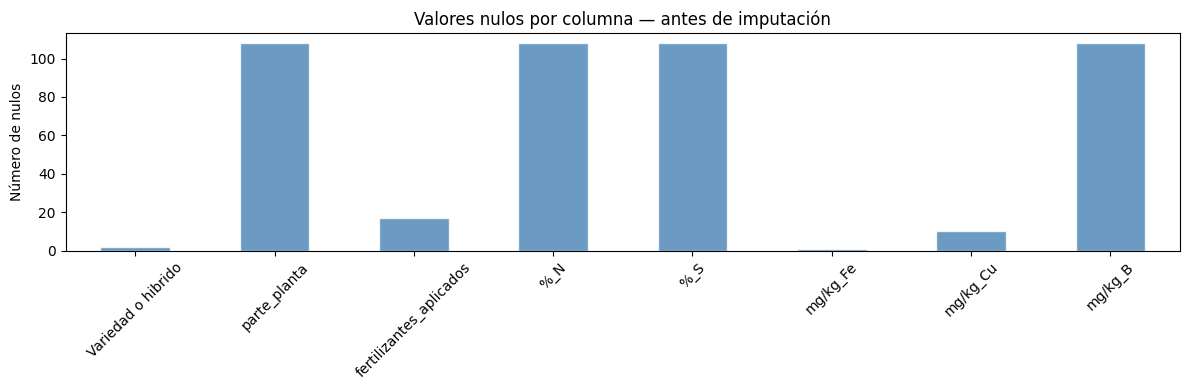

In [ ]:
plt.figure(figsize=(12, 4))
nulos[nulos > 0].plot(kind='bar', color='steelblue', alpha=0.8, edgecolor='white')
plt.title('Valores nulos por columna — antes de imputación')
plt.ylabel('Número de nulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Relaciones tabulares — Consultas con Pandas (Sesión 03)

Exploramos relaciones entre variables usando agrupaciones. Esto equivale a hacer consultas SQL sobre el dataset.

In [ ]:
# Consulta 1: promedio de macronutrientes por cultivo (top 10)
print('Promedio de N, P, K por cultivo')
df2.groupby('cultivo')[['%_N', '%_P', '%_K']].mean().round(3)\
   .sort_values('%_N', ascending=False).head(10)

Promedio de N, P, K por cultivo


,%_N,%_P,%_K
cultivo,,,
PROTEINA DE SOYA,10.010,0.710,1.830
SOYA,5.871,0.452,1.952
DIETA CAMPANARIO,5.630,1.140,2.060
ARTEMISIA,5.250,0.380,2.850
FIRJOL,4.985,0.445,2.165
CHICALA,4.917,0.597,2.740
GLIRICIDIA,4.737,0.313,2.550
CANNABIS MEDICINAL,4.590,0.638,3.165
FRIJOL,4.562,0.381,1.951


In [ ]:
# Consulta 2: conteo de rendimiento por departamento
print('Rendimiento por departamento')
df2[df2['rendimiento'] != 'NO INDICA']\
   .groupby(['departamento', 'rendimiento']).size()\
   .reset_index(name='total')\
   .sort_values('total', ascending=False).head(20)

Rendimiento por departamento


,departamento,rendimiento,total
25,MAGDALENA,BUENO,466
46,VALLE DEL CAUCA,BUENO,374
43,TOLIMA,BUENO,355
41,SANTANDER,BUENO,297
21,CUNDINAMARCA,REGULAR,253
33,NO INDICA,BUENO,209
0,ANTIOQUIA,BUENO,192
3,ATLÁNTICO,BUENO,150
31,NARIÑO,MALO,119
2,ANTIOQUIA,REGULAR,102


In [ ]:
# Consulta 3: cultivos con más casos de rendimiento MALO
print('Top cultivos con rendimiento MALO')
df2[df2['rendimiento'] == 'MALO']\
   .groupby('cultivo').size()\
   .reset_index(name='casos_malos')\
   .sort_values('casos_malos', ascending=False).head(10)

Top cultivos con rendimiento MALO


,cultivo,casos_malos
6,COCO,110
11,PALMA DE ACEITE,12
3,CACAO,6
4,CAFÉ,5
0,AGUACATE,4
1,ARÁNDANO,1
2,BROCOLI,1
7,FRAMBUESA,1
5,CANNABIS MEDICINAL,1
8,FRIJOL,1


## 5. Exploración e ingeniería de variables,limpieza e imputación (Sesión 04 y 05)

Antes de transformar, exploramos los valores reales de cada variable categórica para tomar decisiones informadas.

In [ ]:
#VER TODOS LOS VALORES — ejecutar primero
print(' 170 CULTIVOS')
print(df2['cultivo'].value_counts().head(170).to_string())

print('\n=== PARTE DE LA PLANTA ===')
print(df2['parte_planta'].value_counts().to_string())

print('\n=== EDAD DEL CULTIVO (top 30) ===')
print(df2['edad_cultivo'].value_counts().head(30).to_string())

print('\n=== FERTILIZANTES APLICADOS ===')
print(df2['fertilizantes_aplicados'].value_counts().to_string())

 170 CULTIVOS
cultivo
CACAO                                        863
AGUACATE                                     744
ARROZ                                        596
ARVEJA                                       556
MANGO                                        527
CAÑA PANELERA                                456
FRIJOL                                       435
CAÑA DE AZUCAR                               361
PAPA CRIOLLA                                 360
PLÁTANO                                      358
PAPA                                         352
MORA                                         298
CÍTRICOS                                     243
MAÍZ                                         239
CEBOLLA DE RAMA                              228
ALBAHACA                                     225
PALMA DE ACEITE                              210
QUINUA                                       205
GUAYABA                                      204
PASTOS                                       19

### 5.1 Cultivo — agrupar top 50 + OTROS
Con 170 cultivos distintos, LabelEncoder crearía demasiadas categorías. Conservamos los 50 más frecuentes.

In [ ]:
top_cultivos = df2['cultivo'].value_counts().head(50).index.tolist()
print('Top 50 cultivos seleccionados:')
for i, c in enumerate(top_cultivos, 1):
    n = df2['cultivo'].value_counts()[c]
    print(f'  {i:2}. {c}: {n} registros')

df2['cultivo_agrupado'] = df2['cultivo'].apply(
    lambda x: x if x in top_cultivos else 'OTROS'
)
print(f'\nDistribución cultivo_agrupado:')
print(df2['cultivo_agrupado'].value_counts().to_string())

Top 50 cultivos seleccionados:
   1. CACAO: 863 registros
   2. AGUACATE: 744 registros
   3. ARROZ: 596 registros
   4. ARVEJA: 556 registros
   5. MANGO: 527 registros
   6. CAÑA PANELERA: 456 registros
   7. FRIJOL: 435 registros
   8. CAÑA DE AZUCAR: 361 registros
   9. PAPA CRIOLLA: 360 registros
  10. PLÁTANO: 358 registros
  11. PAPA: 352 registros
  12. MORA: 298 registros
  13. CÍTRICOS: 243 registros
  14. MAÍZ: 239 registros
  15. CEBOLLA DE RAMA: 228 registros
  16. ALBAHACA: 225 registros
  17. PALMA DE ACEITE: 210 registros
  18. QUINUA: 205 registros
  19. GUAYABA: 204 registros
  20. PASTOS: 190 registros
  21. COCO: 190 registros
  22. BATATA: 162 registros
  23. CEBOLLA DE BULBO: 158 registros
  24. TOMATE: 154 registros
  25. MARACUYÁ: 135 registros
  26. MARAÑÓN: 127 registros
  27. ARRACACHA: 110 registros
  28. AJI: 108 registros
  29. YUCA: 106 registros
  30. MADERABLE: 104 registros
  31. BANANO: 98 registros
  32. CAFÉ: 93 registros
  33. LIMA ACIDA: 68 regist

### 5.2 Parte de la planta — agrupar
Conservamos las partes con más de 100 registros, el resto como OTRA.

In [ ]:
top_partes = df2['parte_planta'].value_counts()
top_partes = top_partes[top_partes > 100].index.tolist()
print(f'Partes conservadas (>100 registros): {top_partes}')

df2['parte_planta_agrupada'] = df2['parte_planta'].apply(
    lambda x: x if x in top_partes else 'OTRA'
)
print('\nDistribución agrupada:')
print(df2['parte_planta_agrupada'].value_counts().to_string())

Partes conservadas (>100 registros): ['HOJAS', 'FRUTO', 'TALLOS', 'PARTE ÁREA', 'FOLIOLOS', 'RAIZ', 'HOJAS Y TALLOS', 'YAGUAS', 'GRANO', 'COGOLLOS', 'SEMILLA', 'TODA LA PLANTA', 'CÁSCARA', 'PSEUDOTALLO']

Distribución agrupada:
parte_planta_agrupada
HOJAS             5118
FRUTO              894
OTRA               635
TALLOS             585
PARTE ÁREA         559
FOLIOLOS           385
RAIZ               345
HOJAS Y TALLOS     280
YAGUAS             219
GRANO              191
COGOLLOS           189
SEMILLA            184
TODA LA PLANTA     161
CÁSCARA            159
PSEUDOTALLO        123


### 5.3 Fertilizantes — binarizar
Convertimos 159 valores únicos en: ¿aplicó fertilizante? (0=No, 1=Sí). Esto captura la información útil sin el ruido de los distintos nombres.

In [ ]:
# Valores que significan NO aplicó
no_aplica = ['NO INDICA', 'NINGUNO', 'NO APLICA', 'N/A', 'NAN',
             'NONE', 'NO', 'SIN FERTILIZANTE', 'NO FERTILIZA',
             'NINGUNA', 'NO REGISTRA', 'NO SE APLICO', 'NO APLICA']

df2['fertilizante_bin'] = df2['fertilizantes_aplicados'].apply(
    lambda x: 0 if str(x).upper().strip() in no_aplica else 1
)

print('Distribución fertilizante_bin:')
print(f'  No aplicó (0): {(df2["fertilizante_bin"]==0).sum()}')
print(f'  Sí aplicó (1): {(df2["fertilizante_bin"]==1).sum()}')

Distribución fertilizante_bin:
  No aplicó (0): 7479
  Sí aplicó (1): 2548


### 5.4 Edad del cultivo — convertir a número
Esta columna es muy heterogénea: tiene años, meses, símbolos < y >, texto descriptivo. La convertimos toda a **años numéricos**.

In [ ]:
def convertir_edad(valor):
    s = str(valor).upper().strip()

    # Casos nulos o sin dato
    if s in ['NAN', 'NO INDICA', 'N/A', '', 'NONE', 'NO APLICA']:
        return np.nan

    # Meses → convertir a años
    if 'MES' in s:
        try:
            num = float(''.join(c for c in s.split('MES')[0]
                          if c.isdigit() or c in '.,').replace(',', '.'))
            return round(num / 12, 2)
        except:
            return np.nan


    # Años explícito
    if 'AÑO' in s or 'ANO' in s:
        try:
            num = float(''.join(c for c in s.split('AÑO')[0]
                          if c.isdigit() or c in '.,').replace(',', '.'))
            return num
        except:
            return np.nan

    # Menor que → mitad del valor (LOD/2)
    if s.startswith('<'):
        try:
            return float(s.replace('<','').replace(',','.').strip()) / 2
        except:
            return np.nan

    # Mayor que → valor + 1
    if s.startswith('>'):
        try:
            return float(s.replace('>','').replace(',','.').strip()) + 1
        except:
            return np.nan

    # Texto descriptivo → nulo
    if s in ['ADULTO','MADURO','ESTABLECIDO','JOVEN','NUEVO','RECIENTE']:
        return np.nan

    # Número directo
    try:
        return float(s.replace(',', '.'))
    except:
        return np.nan

df2['edad_num'] = df2['edad_cultivo'].apply(convertir_edad)

print('Resultado conversión edad:')
print(df2['edad_num'].describe().round(2))
print(f'\nNulos: {df2["edad_num"].isnull().sum()}')
print(f'Convertidos: {df2["edad_num"].notna().sum()}')

Resultado conversión edad:
count    1863.00
mean       10.21
std        66.36
min         0.08
25%         0.38
50%         1.33
75%         6.00
max       910.00
Name: edad_num, dtype: float64

Nulos: 8164
Convertidos: 1863


In [ ]:
porcentaje_nulos_edad_num = df2['edad_num'].isnull().sum() / len(df2) * 100
print(f'Porcentaje de nulos en la columna edad_num: {porcentaje_nulos_edad_num:.2f}%')

Porcentaje de nulos en la columna edad_num: 70.36%


In [ ]:
# Ver qué valores quedaron como NaN — por si hay algo recuperable
mask_nulos = df2['edad_num'].isnull()
print('Valores de edad_cultivo que quedaron como NaN:')
print(df2.loc[mask_nulos, 'edad_cultivo'].value_counts().head(20).to_string())

Valores de edad_cultivo que quedaron como NaN:
edad_cultivo
NO INDICA      7050
2DA SIEMBRA       5


### 5.5 Eliminar columnas innecesarias

In [ ]:
# Ver exactamente qué columnas existen en df2 ahora
print(df2.columns.tolist())

['fecha_registro', 'departamento', 'rendimiento', '%_N', '%_P', '%_K', '%_Ca', '%_Mg', '%_Na', '%_S', 'mg/kg_Fe', 'mg/kg_Cu', 'mg/kg_Mn', 'mg/kg_Zn', 'mg/kg_B', 'cultivo_agrupado', 'parte_planta_agrupada', 'fertilizante_bin']


In [ ]:
# Eliminar columnas originales que ya fueron transformadas o no aportan al modelo
# municipio: 224 únicos — demasiado granular
# Variedad o hibrido: 421 únicos — muy heterogéneo
# sintomatologia: texto libre heterogéneo
# fertilizantes_aplicados: reemplazada por fertilizante_bin (0/1)
# cultivo: reemplazada por cultivo_agrupado
# parte_planta: reemplazada por parte_planta_agrupada
# edad_cultivo: reemplazada por edad_num (pero se excluirá del modelo por 70% nulos)

cols_eliminar = ['municipio', 'Variedad o hibrido', 'sintomatologia',
                 'fertilizantes_aplicados', 'cultivo',
                 'parte_planta', 'edad_cultivo']

cols_eliminar = [c for c in cols_eliminar if c in df2.columns]
df2 = df2.drop(columns=cols_eliminar)

print(f' Eliminadas: {cols_eliminar}')
print(f'Columnas restantes ({df2.shape[1]}):')
print(df2.columns.tolist())

 Eliminadas: []
Columnas restantes (18):
['fecha_registro', 'departamento', 'rendimiento', '%_N', '%_P', '%_K', '%_Ca', '%_Mg', '%_Na', '%_S', 'mg/kg_Fe', 'mg/kg_Cu', 'mg/kg_Mn', 'mg/kg_Zn', 'mg/kg_B', 'cultivo_agrupado', 'parte_planta_agrupada', 'fertilizante_bin']


La lógica de los instrumentos de laboratorios es que si el instrumento no detecta por debajo de 0,03, sabemos que el valor real está entre 0 y 0,03. El mejor estimador sin más información es el punto medio: 0,015.Esto se llama sustitución por LOD/2 (Limit of Detection / 2) y es el estándar internacional (EPA, FAO, OMS).

In [ ]:
cols_float = ['%_Ca', '%_Mg', '%_Na', '%_S',
              'mg/kg_Fe', 'mg/kg_Cu', 'mg/kg_Mn', 'mg/kg_Zn', 'mg/kg_B']

def limpiar_menor_que(valor):
    s = str(valor).strip()
    if s.startswith('<'):
        numero = float(s.replace('<','').replace(',','.').strip())
        return numero / 2  # LOD/2 — estándar internacional
    try:
        return float(s.replace(',','.'))
    except:
        return np.nan

df3 = df2.copy()
for col in cols_float:
    if col in df3.columns:
        df3[col] = df3[col].apply(limpiar_menor_que)

print('Limpieza LOD/2 aplicada')
print(df3[cols_float].dtypes)
df3[cols_float].head(7)

Limpieza LOD/2 aplicada
%_Ca        float64
%_Mg        float64
%_Na        float64
%_S         float64
mg/kg_Fe    float64
mg/kg_Cu    float64
mg/kg_Mn    float64
mg/kg_Zn    float64
mg/kg_B     float64
dtype: object


,%_Ca,%_Mg,%_Na,%_S,mg/kg_Fe,mg/kg_Cu,mg/kg_Mn,mg/kg_Zn,mg/kg_B
0,0.73,0.38,0.015,0.36,136.28,9.10,83.27,113.28,51.84
1,0.65,0.35,0.015,0.32,94.62,8.16,153.64,79.40,45.48
2,0.66,0.38,0.015,0.38,91.61,7.98,74.81,116.97,46.20
3,0.67,0.33,0.015,0.37,94.82,9.15,85.17,176.41,43.25
4,0.88,0.41,0.015,0.34,124.98,7.99,137.37,181.06,46.62
5,0.71,0.37,0.015,0.35,107.91,8.81,126.89,204.01,45.38
6,0.63,0.31,0.015,0.36,111.63,6.99,69.85,61.78,56.64


## 7. Conversión de fecha y codificación de categóricas

In [ ]:
df4 = df3.copy()
df4['fecha_registro'] = pd.to_datetime(df4['fecha_registro']).dt.normalize()

print('Rango de fechas:')
print(f'  Desde: {df4["fecha_registro"].min().date()}')
print(f'  Hasta: {df4["fecha_registro"].max().date()}')

Rango de fechas:
  Desde: 2018-01-10
  Hasta: 2024-12-18


In [ ]:
le_depto   = LabelEncoder()
le_cultivo = LabelEncoder()
le_parte   = LabelEncoder()

df4['departamento_cod']     = le_depto.fit_transform(df4['departamento'].fillna('DESCONOCIDO'))
df4['cultivo_agrupado_cod'] = le_cultivo.fit_transform(df4['cultivo_agrupado'].fillna('OTROS'))
df4['parte_planta_cod']     = le_parte.fit_transform(df4['parte_planta_agrupada'].fillna('OTRA'))

print('Variables categóricas codificadas')
print(f'  departamento: {df4["departamento_cod"].nunique()} categorías')
print(f'  cultivo:      {df4["cultivo_agrupado_cod"].nunique()} categorías')
print(f'  parte_planta: {df4["parte_planta_cod"].nunique()} categorías')

Variables categóricas codificadas
  departamento: 26 categorías
  cultivo:      51 categorías
  parte_planta: 15 categorías


In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10027 entries, 0 to 10026
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   fecha_registro         10027 non-null  datetime64[ns]
 1   departamento           10027 non-null  object        
 2   rendimiento            10027 non-null  object        
 3   %_N                    9919 non-null   float64       
 4   %_P                    10027 non-null  float64       
 5   %_K                    10027 non-null  float64       
 6   %_Ca                   10027 non-null  float64       
 7   %_Mg                   10027 non-null  float64       
 8   %_Na                   10027 non-null  float64       
 9   %_S                    9919 non-null   float64       
 10  mg/kg_Fe               10025 non-null  float64       
 11  mg/kg_Cu               10017 non-null  float64       
 12  mg/kg_Mn               10026 non-null  float64       
 13  m

In [ ]:
print('Valores únicos por columna:')
print(df4.nunique())

Valores únicos por columna:
fecha_registro            429
departamento               26
rendimiento                 4
%_N                       594
%_P                       124
%_K                       822
%_Ca                      521
%_Mg                      169
%_Na                      105
%_S                       167
mg/kg_Fe                 8179
mg/kg_Cu                 1971
mg/kg_Mn                 7838
mg/kg_Zn                 5615
mg/kg_B                  5313
cultivo_agrupado           51
parte_planta_agrupada      15
fertilizante_bin            2
departamento_cod           26
cultivo_agrupado_cod       51
parte_planta_cod           15
dtype: int64


## 8. Imputación de nulos y filtrado (Sesiones 04 y 05)

### 8.1 Imputar nulos en nutrientes
Usamos la **mediana** porque los nutrientes tienen distribución sesgada con valores extremos y porque el porcentaje de mulos para elementos es poca y la diferencia entre metodos no era garnde.

In [ ]:
cols_nutrientes = ['%_N', '%_P', '%_K', '%_Ca', '%_Mg', '%_Na',
                   '%_S', 'mg/kg_Fe', 'mg/kg_Cu', 'mg/kg_Mn',
                   'mg/kg_Zn', 'mg/kg_B']

for col in cols_nutrientes:
    n_nulos = df4[col].isnull().sum()
    if n_nulos > 0:
        mediana = df4[col].median()
        df4[col] = df4[col].fillna(mediana)
        print(f'  {col}: {n_nulos} nulos → mediana = {mediana:.4f}')

print(f'\n Nulos restantes en nutrientes: {df4[cols_nutrientes].isnull().sum().sum()}')


 Nulos restantes en nutrientes: 0


### 8.2 Filtrar NO INDICA

Los registros 'NO INDICA' en rendimiento son datos faltantes en la **variable objetivo**. No se pueden imputar porque predecir el rendimiento es exactamente lo que el modelo va a aprender por lo cual decidimos eliminarlos, aunque se perdiera mucha data.

### 8.3 Manejo del desbalance con class_weight

Sin embargo el data set queda desbalanceado pero En lugar de eliminar datos con balanceo manual que nos limitaría aun más, usamos `class_weight='balanced'` en cada modelo. Esto le indica al modelo que penalice más los errores en clases minoritarias **sin perder ninguna fila**.

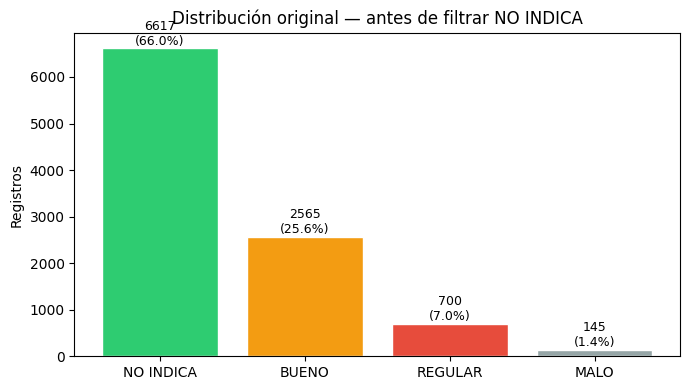

In [ ]:
# Distribución ANTES de filtrar
plt.figure(figsize=(7,4))
conteo = df4['rendimiento'].value_counts()
colores = ['#2ecc71','#f39c12','#e74c3c','#95a5a6']
plt.bar(conteo.index, conteo.values, color=colores, edgecolor='white')
plt.title('Distribución original — antes de filtrar NO INDICA')
plt.ylabel('Registros')
for i, v in enumerate(conteo.values):
    plt.text(i, v+80, f'{v}\n({v/len(df4)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
df_modelo = df4[df4['rendimiento'] != 'NO INDICA'].copy()
df_modelo = df_modelo.reset_index(drop=True)

print(f'Filas antes:   {len(df4)}')
print(f'Filas después: {len(df_modelo)}')
print(f'Eliminadas:    {len(df4)-len(df_modelo)} (solo los NO INDICA)')
print(f'\nClases disponibles:')
print(df_modelo['rendimiento'].value_counts())

Filas antes:   10027
Filas después: 3410
Eliminadas:    6617 (solo los NO INDICA)

Clases disponibles:
rendimiento
BUENO      2565
REGULAR     700
MALO        145
Name: count, dtype: int64


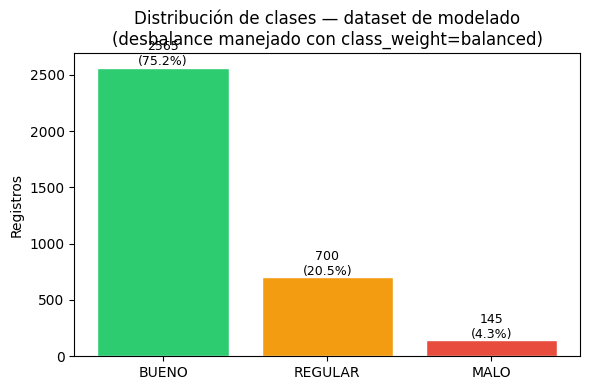

In [ ]:
# Visualizar desbalance — se maneja con class_weight en modelos
plt.figure(figsize=(6,4))
conteo_m = df_modelo['rendimiento'].value_counts()
plt.bar(conteo_m.index, conteo_m.values,
        color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
plt.title('Distribución de clases — dataset de modelado\n(desbalance manejado con class_weight=balanced)')
plt.ylabel('Registros')
for i, v in enumerate(conteo_m.values):
    plt.text(i, v+20, f'{v}\n({v/len(df_modelo)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
le_rend = LabelEncoder()
df_modelo['rendimiento_cod'] = le_rend.fit_transform(df_modelo['rendimiento'])

print('Codificación de la variable objetivo:')
for clase, cod in zip(le_rend.classes_, le_rend.transform(le_rend.classes_)):
    print(f'  {clase} → {cod}')

Codificación de la variable objetivo:
  BUENO → 0
  MALO → 1
  REGULAR → 2


In [ ]:
cols_modelo = cols_nutrientes + ['departamento_cod', 'cultivo_agrupado_cod',
                                  'parte_planta_cod', 'fertilizante_bin']

print(f'Total variables para el modelo: {len(cols_modelo)}')
for c in cols_modelo:
    print(f'  - {c}')

Total variables para el modelo: 16
  - %_N
  - %_P
  - %_K
  - %_Ca
  - %_Mg
  - %_Na
  - %_S
  - mg/kg_Fe
  - mg/kg_Cu
  - mg/kg_Mn
  - mg/kg_Zn
  - mg/kg_B
  - departamento_cod
  - cultivo_agrupado_cod
  - parte_planta_cod
  - fertilizante_bin


## 9. Análisis exploratorio visual — Preprocesamiento (Sesión 05)

In [ ]:
#estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS — NUTRIENTES ')
df_modelo[cols_nutrientes].describe().round(3)

ESTADÍSTICAS DESCRIPTIVAS — NUTRIENTES 


,%_N,%_P,%_K,%_Ca,%_Mg,%_Na,%_S,mg/kg_Fe,mg/kg_Cu,mg/kg_Mn,mg/kg_Zn,mg/kg_B
count,3410.00,3410.000,3410.000,3410.000,3410.000,3410.000,3410.000,3410.000,3410.000,3410.000,3410.000,3410.000
mean,2.26,0.221,1.811,1.158,0.294,0.044,0.238,217.322,8.007,169.964,31.222,41.136
std,1.25,0.177,1.418,1.172,0.196,0.128,0.198,1498.129,14.123,245.342,34.805,46.328
min,0.12,0.030,0.030,0.020,0.015,0.015,0.003,6.390,0.780,2.500,0.750,0.500
25%,1.26,0.130,0.910,0.240,0.140,0.015,0.130,41.728,4.212,15.318,11.960,14.432
50%,2.17,0.180,1.370,0.790,0.260,0.015,0.200,80.470,5.910,63.230,18.165,28.870
75%,2.87,0.250,2.020,1.690,0.400,0.015,0.300,146.612,8.428,232.935,38.830,50.398
max,7.29,3.820,9.360,7.710,2.290,2.400,2.090,50891.970,533.610,3320.750,358.970,946.790


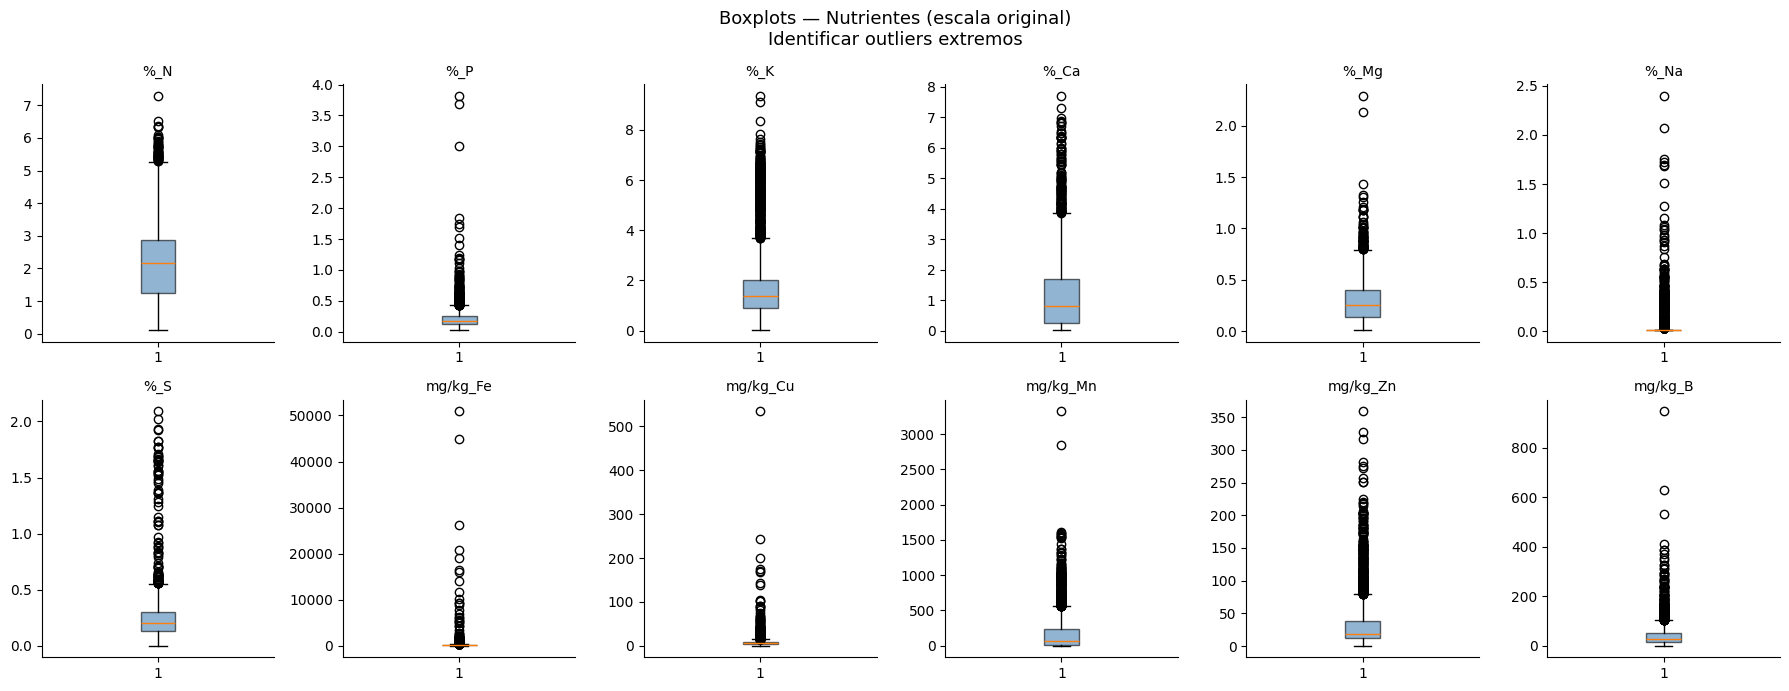

In [ ]:
# Boxplots escala original — identificar outliers
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(cols_nutrientes):
    axes[i].boxplot(df_modelo[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].spines[['top','right']].set_visible(False)
fig.suptitle('Boxplots — Nutrientes (escala original)\nIdentificar outliers extremos', fontsize=13)
plt.tight_layout()
plt.show()

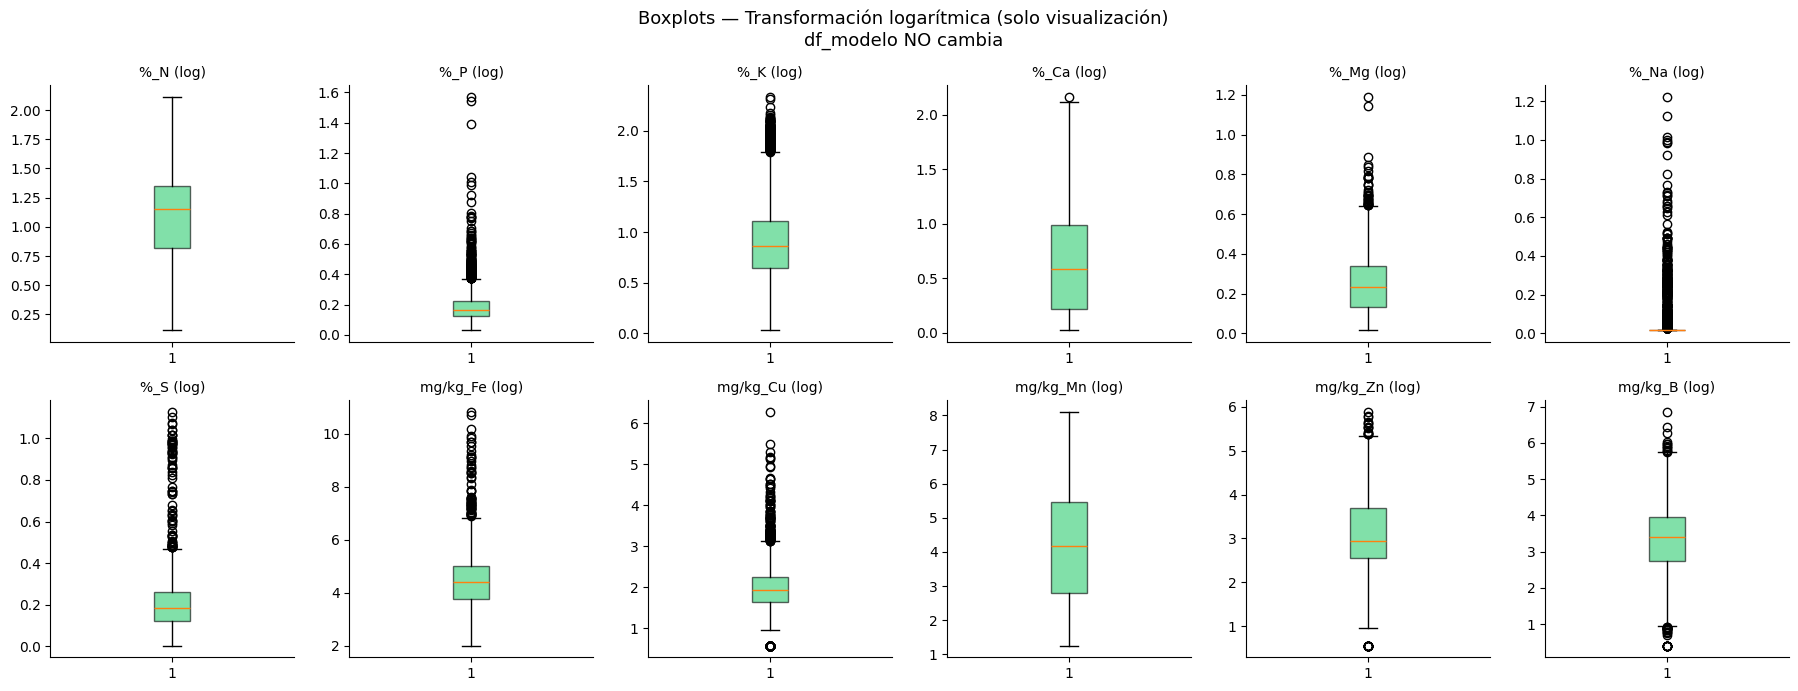

In [ ]:
# Transformación logarítmica — SOLO para visualización
# log1p comprime outliers extremos para ver mejor la distribución interna
# NO modifica df_modelo — solo se usa para los boxplots
df_log = df_modelo[cols_nutrientes].apply(lambda x: np.log1p(x))

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(cols_nutrientes):
    axes[i].boxplot(df_log[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.6))
    axes[i].set_title(f'{col} (log)', fontsize=10)
    axes[i].spines[['top','right']].set_visible(False)
fig.suptitle('Boxplots — Transformación logarítmica (solo visualización)\ndf_modelo NO cambia', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Cuantificar outliers con método IQR
print('Outliers por nutriente (método IQR):')
print(f'{"Nutriente":<15} {"Outliers":>8} {"Porcentaje":>12}')
print('-' * 38)
for col in cols_nutrientes:
    Q1 = df_modelo[col].quantile(0.25)
    Q3 = df_modelo[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = df_modelo[(df_modelo[col] < Q1 - 1.5*IQR) |
                      (df_modelo[col] > Q3 + 1.5*IQR)][col].count()
    pct = n_out / len(df_modelo) * 100
    print(f'{col:<15} {n_out:>8} {pct:>11.1f}%')

Outliers por nutriente (método IQR):
Nutriente       Outliers   Porcentaje
--------------------------------------
%_N                   49         1.4%
%_P                  288         8.4%
%_K                  348        10.2%
%_Ca                 118         3.5%
%_Mg                  68         2.0%
%_Na                 584        17.1%
%_S                  101         3.0%
mg/kg_Fe             211         6.2%
mg/kg_Cu             241         7.1%
mg/kg_Mn             243         7.1%
mg/kg_Zn             249         7.3%
mg/kg_B              230         6.7%


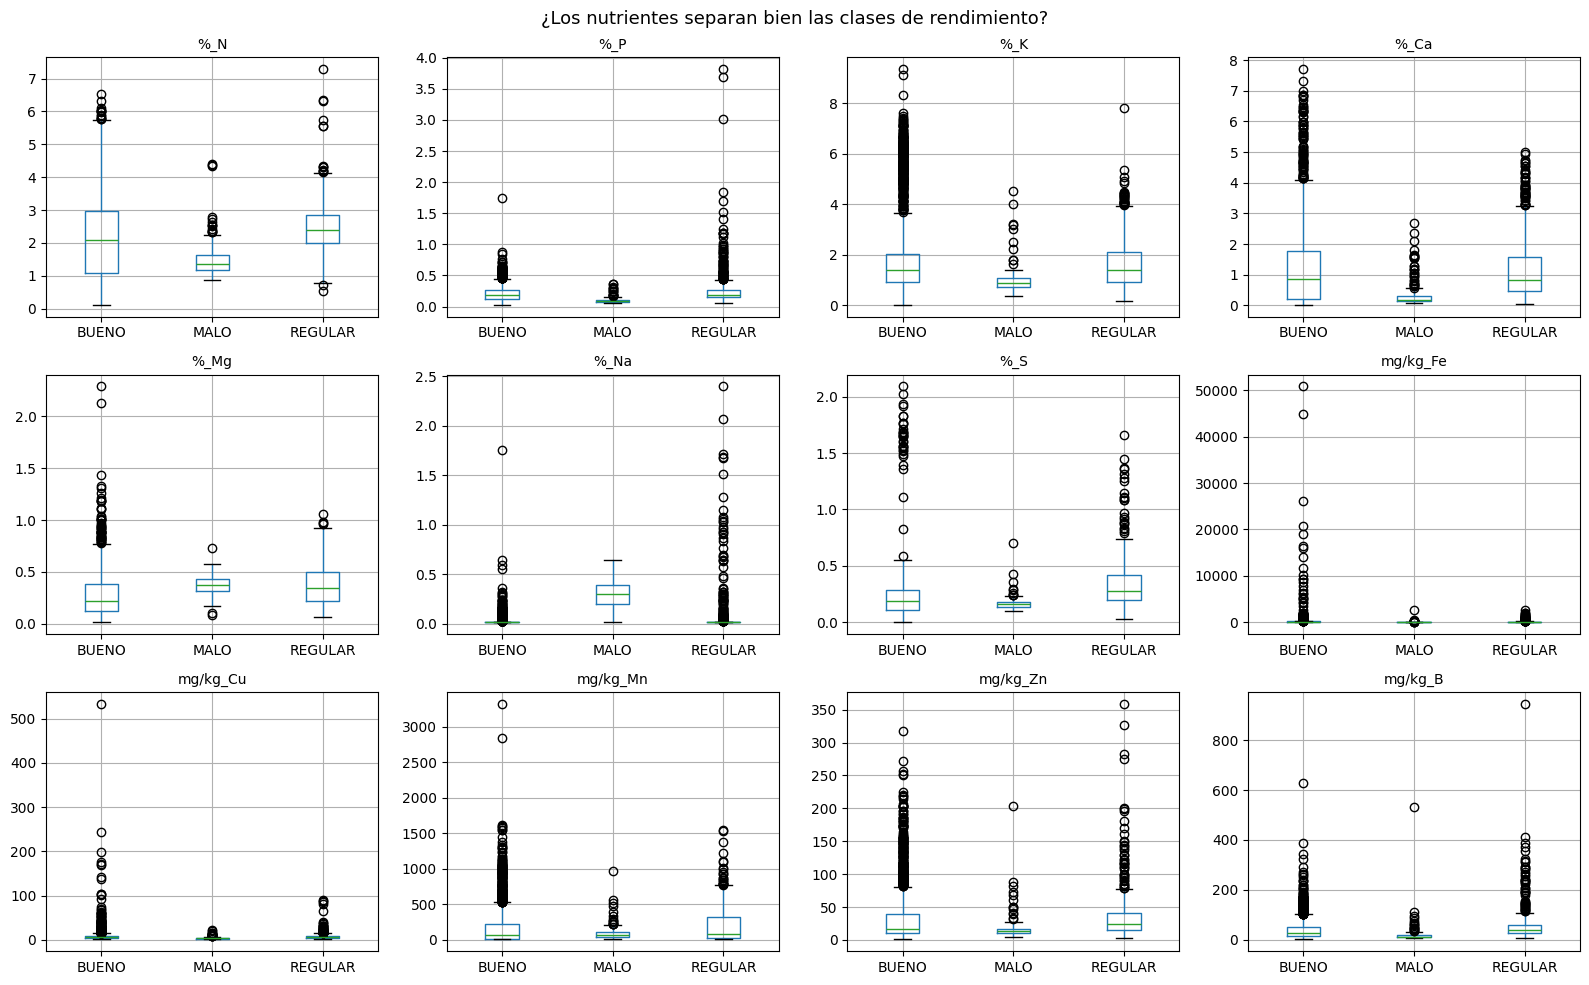

In [ ]:
# Boxplots nutrientes por clase de rendimiento
# Si los boxplots se solapan mucho → el nutriente no discrimina bien entre clases
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cols_nutrientes):
    df_modelo.boxplot(column=col, by='rendimiento', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('¿Los nutrientes separan bien las clases de rendimiento?', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Aplicar clip SOBRE df_modelo directamente — antes del RobustScaler
percentiles_ini = df_modelo[cols_nutrientes].quantile(0.02)
percentiles_fin = df_modelo[cols_nutrientes].quantile(0.98)

df_modelo[cols_nutrientes] = df_modelo[cols_nutrientes].clip(
    lower=percentiles_ini,
    upper=percentiles_fin,
    axis=1
)

print(f'✓ Clip aplicado sobre df_modelo')
print(f'Fe máximo después del clip: {df_modelo["mg/kg_Fe"].max():.2f}')

✓ Clip aplicado sobre df_modelo
Fe máximo después del clip: 853.09


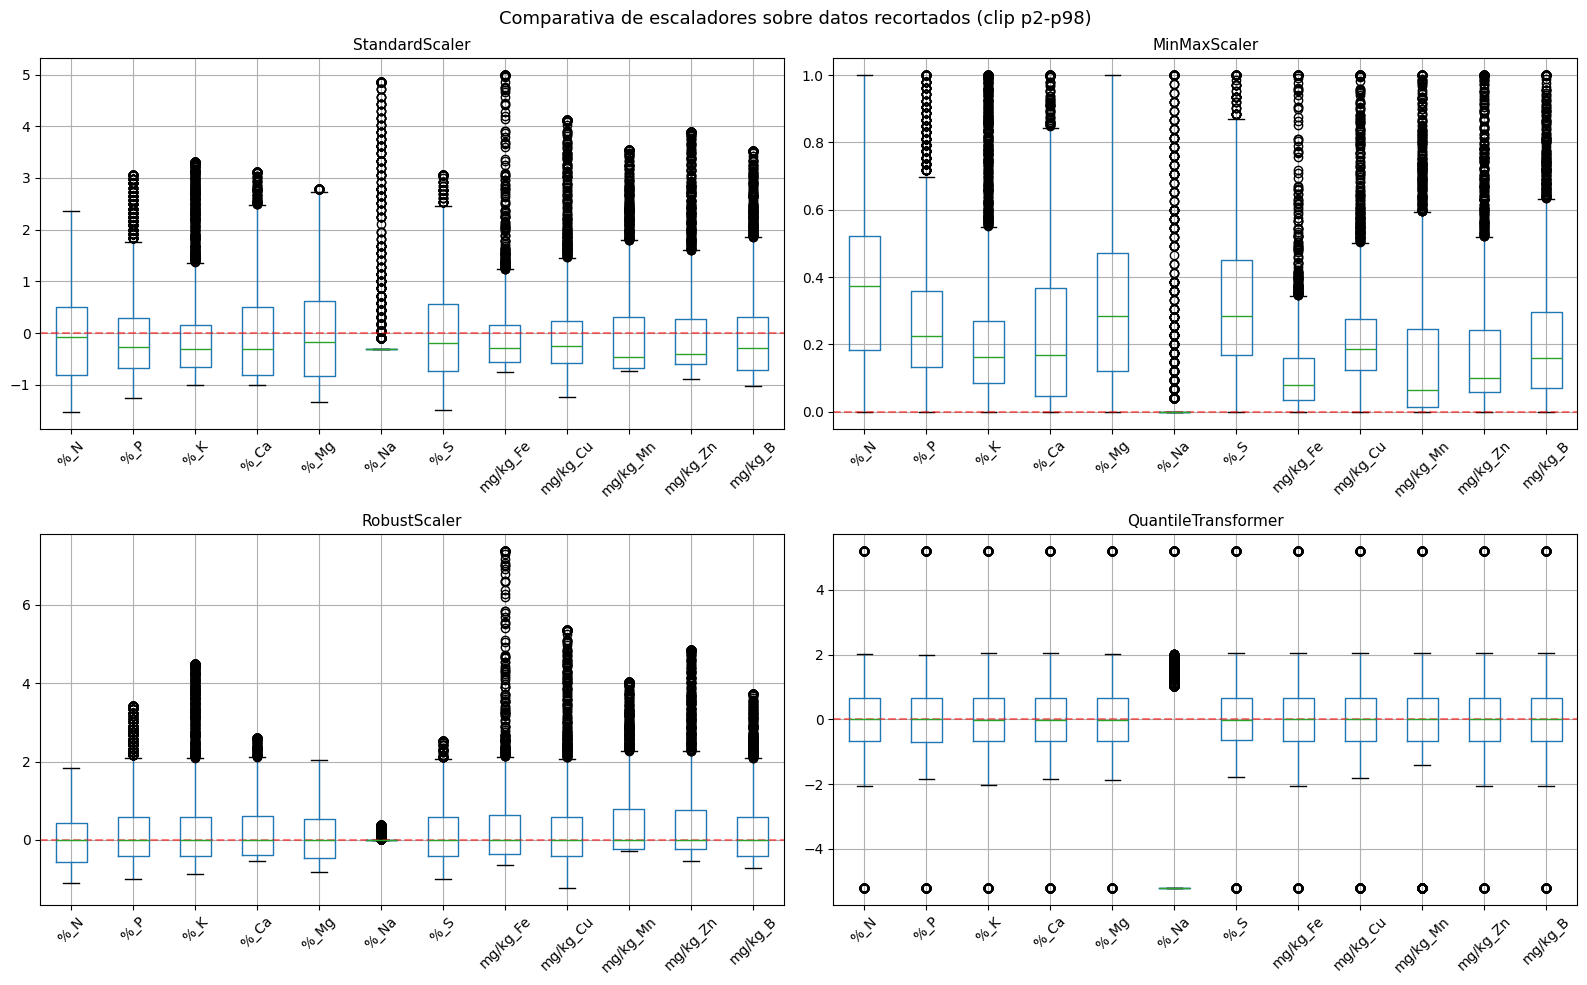

In [ ]:
# Comparativa de escaladores — sobre datos recortados (df_clipped)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler, QuantileTransformer)

escaladores = {
    'StandardScaler'      : StandardScaler(),
    'MinMaxScaler'        : MinMaxScaler(),
    'RobustScaler'        : RobustScaler(),
    'QuantileTransformer' : QuantileTransformer(output_distribution='normal',
                                                random_state=42),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (nombre, esc) in zip(axes, escaladores.items()):
    X_temp = esc.fit_transform(df_clipped)  # ← df_clipped en vez de df_modelo
    X_temp_df = pd.DataFrame(X_temp, columns=cols_nutrientes)
    X_temp_df.boxplot(ax=ax)
    ax.set_title(nombre, fontsize=11)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Comparativa de escaladores sobre datos recortados (clip p2-p98)', fontsize=13)
plt.tight_layout()
plt.show()

La presencia de outliers en micronutrientes es esperable dado
que el dataset integra 171 cultivos en 26 departamentos con
condiciones edáficas muy diversas. Cada cultivo y tipo de suelo
tiene rangos nutricionales distintos, generando distribuciones
amplias con valores extremos legítimos. Solo se eliminaron los
valores de Fe superiores al percentil 99 (>10.000 mg/kg) por
exceder el rango fisiológico foliar documentado en literatura.

In [ ]:
# Aplicar RobustScaler — elegido por ser robusto ante outliers
# Usa mediana e IQR en vez de media y desviación estándar
scaler = RobustScaler()
X = df_modelo[cols_modelo].copy()
y = df_modelo['rendimiento_cod']

X_scaled = scaler.fit_transform(X)
print('RobustScaler aplicado')
print(f'Shape: {X_scaled.shape}')
print('\nMediana después de escalar (~0):')
print(pd.DataFrame(X_scaled, columns=cols_modelo).median().round(2).to_dict())

RobustScaler aplicado
Shape: (3410, 16)

Mediana después de escalar (~0):
{'%_N': 0.0, '%_P': 0.0, '%_K': 0.0, '%_Ca': 0.0, '%_Mg': 0.0, '%_Na': 0.0, '%_S': 0.0, 'mg/kg_Fe': 0.0, 'mg/kg_Cu': 0.0, 'mg/kg_Mn': -0.0, 'mg/kg_Zn': 0.0, 'mg/kg_B': 0.0, 'departamento_cod': 0.0, 'cultivo_agrupado_cod': 0.0, 'parte_planta_cod': 0.0, 'fertilizante_bin': 0.0}


## Interpretación del preprocesamiento y transformación

### Estadísticas descriptivas
Los 3.410 registros del dataset presentan una marcada heterogeneidad
en las unidades de medida. Los macronutrientes (%_N, %_P, %_K, %_Ca,
%_Mg, %_Na, %_S) tienen valores en rangos pequeños (0-9%), mientras
que los micronutrientes (mg/kg_Fe, mg/kg_Cu, mg/kg_Mn, mg/kg_Zn,
mg/kg_B) presentan rangos mucho más amplios, siendo Fe el más extremo
con valores que van desde 6.39 hasta 50.891 mg/kg y una desviación
estándar de 1.498, lo que evidencia alta variabilidad y presencia
de valores atípicos extremos.

### Boxplots escala original
Se identificaron outliers extremos principalmente en los micronutrientes.
El hierro (mg/kg_Fe) presenta el caso más crítico con valores que
superan los 40.000 mg/kg, mientras la mayoría de registros se
concentran cerca de 0. Los macronutrientes muestran distribuciones
más compactas pero con presencia de outliers moderados en %_N, %_K
y %_Ca.

### Transformación logarítmica
La transformación log1p aplicada solo con fines de visualización
reveló que los micronutrientes tienen distribuciones más simétricas
de lo que aparentaban en escala original. mg/kg_Fe pasó de un rango
0-50.000 a un rango 2-10 en escala logarítmica, permitiendo observar
mejor la distribución interna de los datos sin la distorsión de los
outliers extremos.

### ¿Los nutrientes separan las clases de rendimiento?
Los boxplots por clase de rendimiento (BUENO, REGULAR, MALO) muestran
solapamiento considerable en la mayoría de nutrientes, lo que indica
que ningún nutriente por sí solo separa perfectamente las clases.

El Nitrógeno (%_N) es el que muestra mayor diferencia entre clases:
BUENO presenta medianas más altas (~2.17%) que MALO (~1.3%), sugiriendo
que cultivos con mejor rendimiento tienden a tener mayor concentración
foliar de nitrógeno.

Los micronutrientes (Fe, Cu, Mn, Zn, B) no muestran diferencias
claras entre clases, con cajas prácticamente idénticas, lo que sugiere
que su poder discriminatorio individual es bajo.

Este solapamiento general anticipa que el modelo requerirá combinar
múltiples nutrientes para lograr predicciones aceptables.

### Comparativa de escaladores (sobre datos recortados clip p2-p98)
Se compararon cuatro escaladores para determinar el más adecuado:

- **StandardScaler**: las variables quedan centradas en 0 pero los
  micronutrientes siguen mostrando outliers muy pronunciados hacia
  arriba, ya que la media y la desviación estándar se ven afectadas
  por los valores extremos.

- **MinMaxScaler**: lleva todos los valores al rango [0,1] pero
  comprime la mayoría de los datos en valores muy cercanos a 0,
  perdiendo la distribución interna de los datos.

- **RobustScaler**: las cajas de todos los nutrientes quedan
  centradas cerca de 0 con rangos intercuartílicos comparables
  entre sí. Es el escalador que mejor maneja la heterogeneidad
  de unidades y los outliers residuales.

- **QuantileTransformer**: genera distribuciones muy uniformes
  pero aparecen artefactos extremos en −4 y +4 que no corresponden
  a datos reales sino a efectos de la transformación no lineal.

### Decisión final: RobustScaler
Se seleccionó RobustScaler porque:
1. Usa mediana e IQR en lugar de media y desviación estándar,
   siendo insensible a los outliers extremos de Fe, Mn y Zn
2. Produce rangos comparables entre macronutrientes (%) y
   micronutrientes (mg/kg), eliminando el sesgo por unidades
3. La verificación post-escalado confirma mediana = 0 en todas
   las variables, validando la correcta aplicación de la
   transformación X_scaled = (X − mediana) / IQR

## 10. Serie de tiempo — Evolución mensual de nutrientes (Sesión 08)

El dataset cubre 2018–2024. Analizamos la evolución temporal del **Nitrógeno** porque es el nutriente más crítico para el desarrollo vegetal.

In [ ]:
!pip install pmdarima -q

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.6 MB/s eta 0:00:00


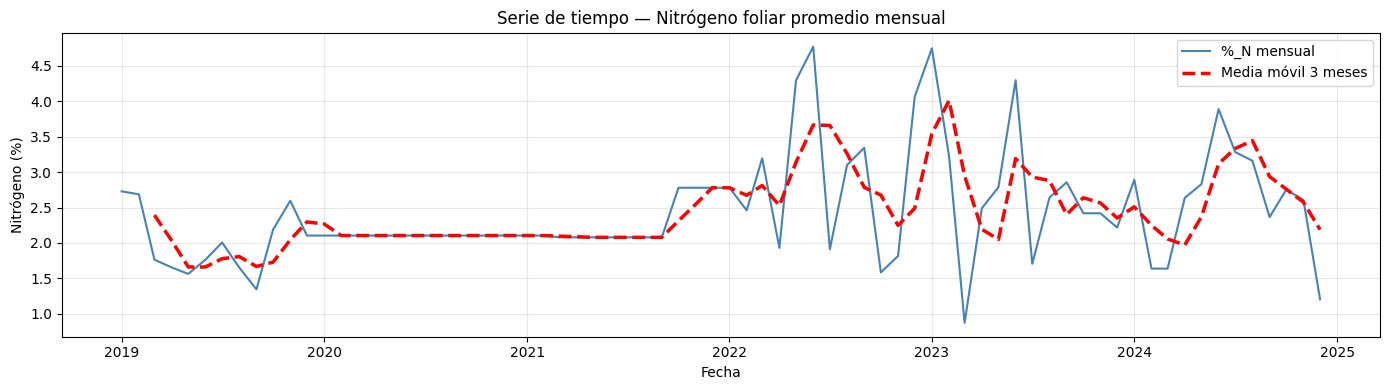

In [ ]:
# Preparar serie mensual de Nitrógeno
serie_N = df_modelo.groupby(
    df_modelo['fecha_registro'].dt.to_period('M'))['%_N'].mean()
serie_N.index = serie_N.index.to_timestamp()
serie_N = serie_N.asfreq('MS')  # frecuencia mensual
serie_N = serie_N.ffill()       # rellenar posibles huecos

# Subset del período con datos más consistentes
start = '2019-01-01'
end   = '2024-12-31'
subset_N = serie_N.loc[start:end]

# Graficar serie
plt.figure(figsize=(14,4))
plt.plot(subset_N, color='steelblue', linewidth=1.5, label='%_N mensual')
plt.plot(subset_N.rolling(3).mean(), color='red', linewidth=2.5,
         linestyle='--', label='Media móvil 3 meses')
plt.title('Serie de tiempo — Nitrógeno foliar promedio mensual')
plt.xlabel('Fecha')
plt.ylabel('Nitrógeno (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Interpretación — Serie de tiempo del Nitrógeno foliar (2018–2024)

La serie muestra el promedio mensual de %_N entre 2018 y 2024,
manteniéndose generalmente entre 1% y 4.7%.

Durante 2020-2021 se observa mayor estabilidad aprox(2.2%), posiblemente
por reducción en la diversidad de cultivos muestreados durante la
pandemia. El pico más alto ocurre en 2022-2023 (~4.7%) seguido de
una caída abrupta, lo que sugiere cambios en los tipos de cultivos
registrados ese período.

La media móvil de 3 meses confirma que la serie es relativamente
estacionaria sin tendencia clara de aumento o disminución, con
oscilaciones alrededor de 2.5%. Las variaciones reflejan principalmente
cambios en el tipo de cultivo muestreado cada mes más que una
tendencia real en la nutrición foliar colombiana.

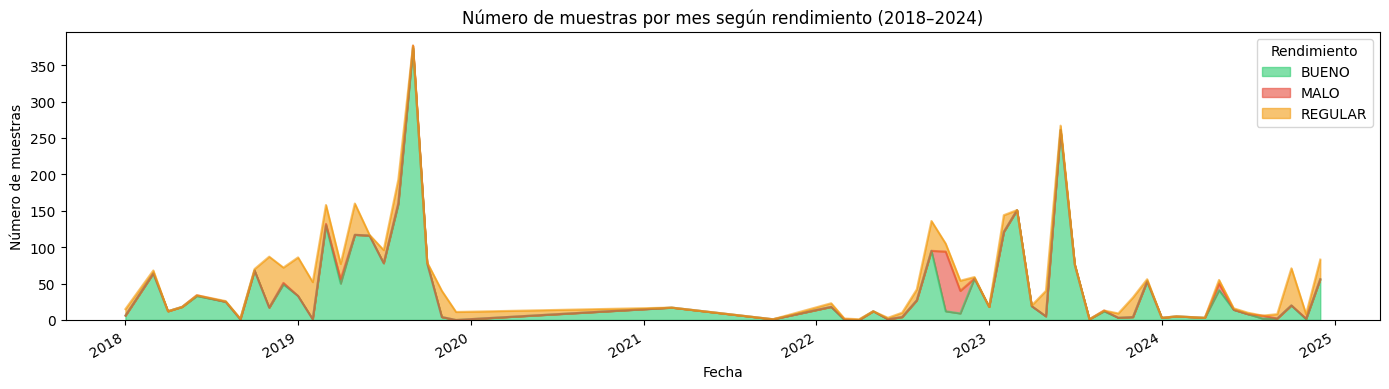

In [ ]:
# Muestras por mes según rendimiento
df_ts = df_modelo.copy()
df_ts['anio_mes'] = df_ts['fecha_registro'].dt.to_period('M')
conteo_t = df_ts.groupby(['anio_mes','rendimiento']).size().unstack(fill_value=0)
conteo_t.index = conteo_t.index.to_timestamp()

conteo_t.plot(kind='area', figsize=(14,4), alpha=0.6,
              color={'BUENO':'#2ecc71','REGULAR':'#f39c12','MALO':'#e74c3c'})
plt.title('Número de muestras por mes según rendimiento (2018–2024)')
plt.xlabel('Fecha')
plt.ylabel('Número de muestras')
plt.legend(title='Rendimiento')
plt.tight_layout()
plt.show()

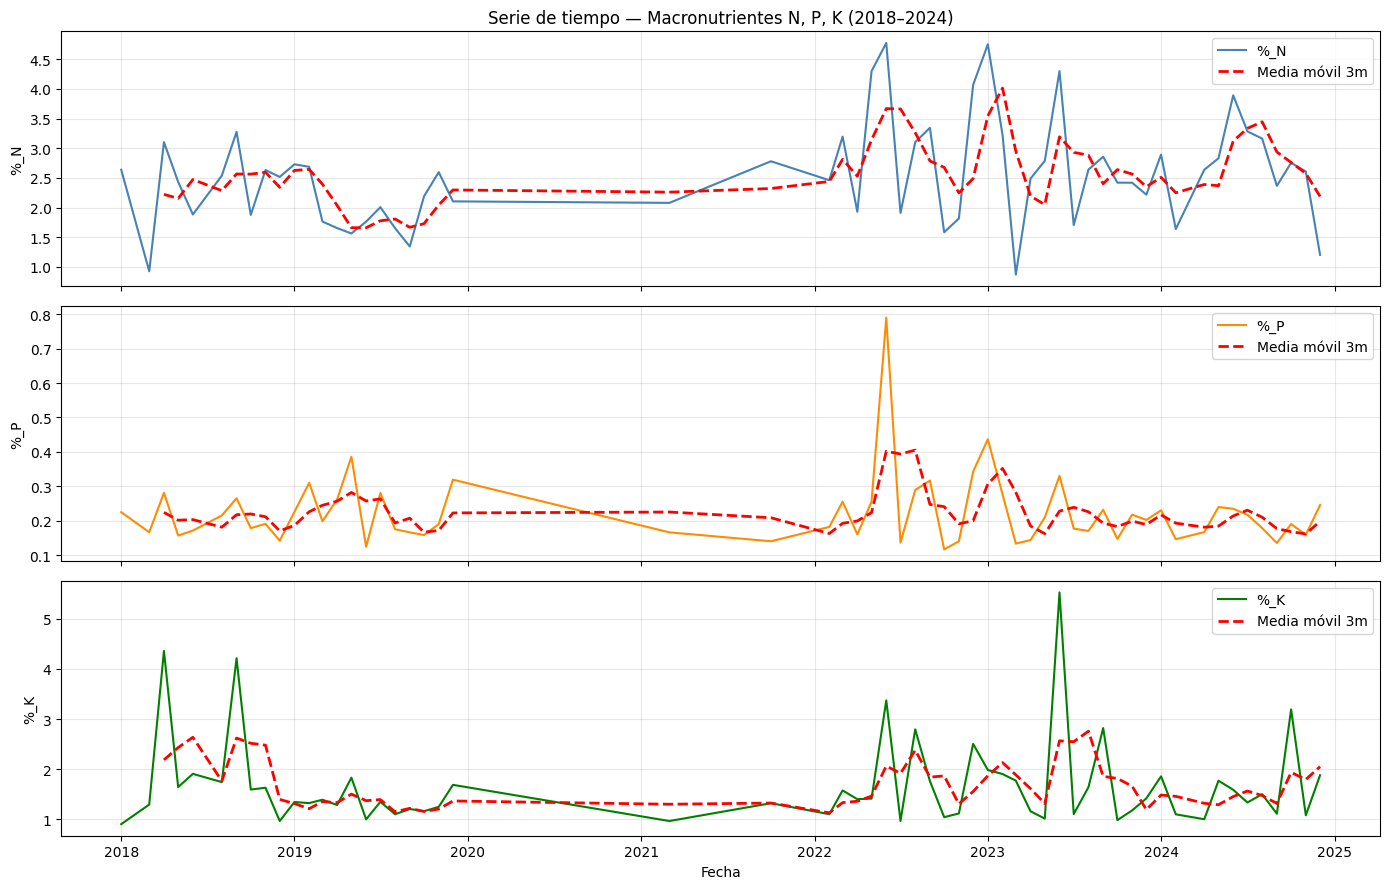

In [ ]:
# Serie de los 3 macronutrientes N, P, K
fig, axes = plt.subplots(3,1, figsize=(14,9), sharex=True)
for ax, nut, color in zip(axes, ['%_N','%_P','%_K'], ['steelblue','darkorange','green']):
    serie = df_modelo.groupby(df_modelo['fecha_registro'].dt.to_period('M'))[nut].mean()
    serie.index = serie.index.to_timestamp()
    ax.plot(serie, color=color, linewidth=1.5, label=nut)
    ax.plot(serie.rolling(3).mean(), color='red', linewidth=2, linestyle='--', label='Media móvil 3m')
    ax.set_ylabel(nut)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
axes[0].set_title('Serie de tiempo — Macronutrientes N, P, K (2018–2024)')
axes[2].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

In [ ]:
# Prueba Dickey-Fuller — ¿es estacionaria la serie?
resultado = adfuller(subset_N)

print(f'Valor p: {resultado[1]:.4f}')

if resultado[1] <= 0.05:
    print('✓ La serie ES estacionaria (p ≤ 0.05)')
    testdiff = 0
else:
    print('✗ La serie NO es estacionaria (p > 0.05)')
    testdiff = 1

Valor p: 0.0000
✓ La serie ES estacionaria (p ≤ 0.05)


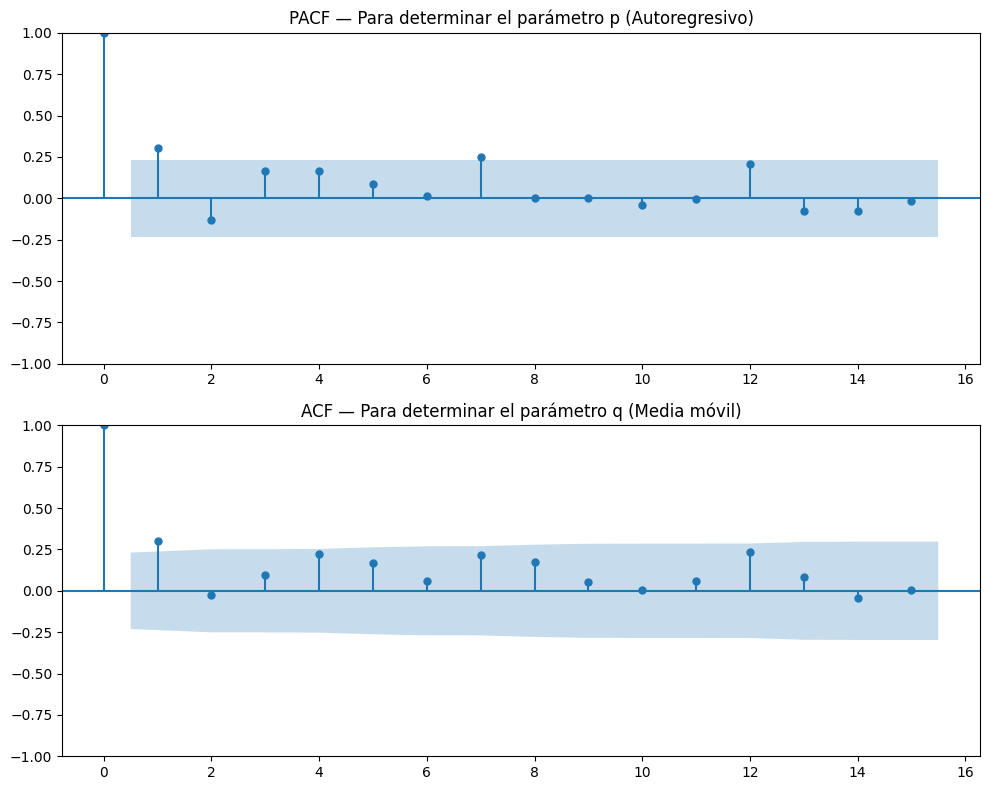

→ p: número de rezagos fuera de la banda azul en PACF
→ q: número de rezagos fuera de la banda azul en ACF


In [ ]:
# ACF y PACF para determinar parámetros p y q del modelo ARIMA
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_pacf(subset_N, ax=ax1, lags=15, method='yw')
ax1.set_title('PACF — Para determinar el parámetro p (Autoregresivo)')

plot_acf(subset_N, ax=ax2, lags=15)
ax2.set_title('ACF — Para determinar el parámetro q (Media móvil)')

plt.tight_layout()
plt.show()

print('→ p: número de rezagos fuera de la banda azul en PACF')
print('→ q: número de rezagos fuera de la banda azul en ACF')

In [ ]:
# Auto ARIMA — busca automáticamente los mejores parámetros
Sarimax_model = auto_arima(subset_N,
                            start_p=0, start_q=0,
                            max_p=3, max_q=4,
                            m=12,
                            test='adf',
                            seasonal=True,
                            d=testdiff, D=testdiff,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

Sarimax_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=168.978, Time=0.87 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=169.680, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=162.524, Time=0.80 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=160.951, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=341.204, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=162.842, Time=0.11 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=162.864, Time=0.80 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=162.721, Time=0.37 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=161.006, Time=0.66 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=162.183, Time=6.25 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=167.230, Time=0.57 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=162.897, Time=0.42 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=162.897, Time=0.25 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=162.385, Time=0.34 sec
 ARIMA(1,0,2)(0,0,1)[12] intercep

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   72
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood                 -76.476
Date:                            Sat, 09 May 2026   AIC                            160.951
Time:                                    21:37:31   BIC                            170.058
Sample:                                01-01-2019   HQIC                           164.577
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.4192      0.152     15.943      0.000       2.122       2.717
ma.L1          0.3644      0.074      4.906      0.000       0.219       0.510
ma.S.L12       0.2319      0.123      1.884      0.060      -0.009       0.473
sigma2         0.4844      0.067      7.222      0.000       0.353       0.616
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                10.60
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               4.90   Skew:                             0.66
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Auto ARIMA con train
Sarimax_model = auto_arima(train,
                            start_p=0, start_q=0,
                            max_p=3, max_q=4,
                            m=12,
                            test='adf',
                            seasonal=True,
                            d=0, D=0,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

print(Sarimax_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=144.287, Time=0.44 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=142.524, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=139.721, Time=0.48 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=138.208, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=283.440, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=137.469, Time=0.07 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=138.218, Time=0.23 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=140.188, Time=1.66 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=139.284, Time=0.59 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=139.257, Time=0.15 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=139.269, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=139.881, Time=0.78 sec
 ARIMA(0,0,1)(0,0,0)[12]             : AIC=232.212, Time=0.05 sec

Best model:  ARIMA(0,0,1)(0,0,0)[12] intercept
Total fit time: 5.093 seconds
                     

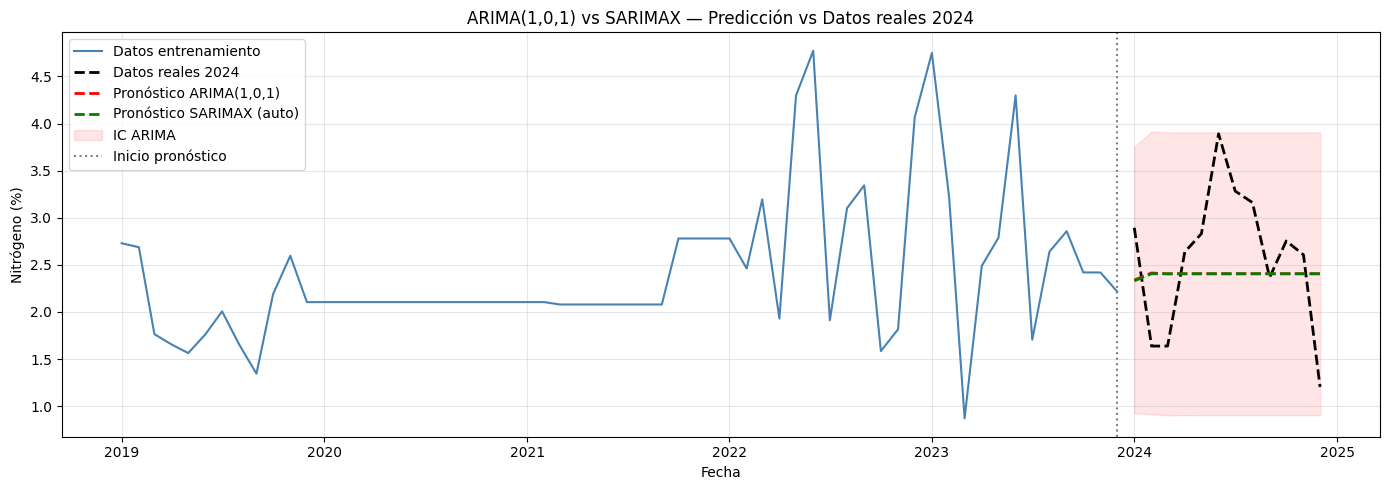

📊 Comparativa de modelos:
Modelo               MAE     RMSE
--------------------------------
ARIMA(1,0,1)      0.6386   0.7576
SARIMAX(auto)     0.6387   0.7574

✓ Mejor modelo: ARIMA (menor MAE)


In [ ]:
# Predicción SARIMAX para el período de test
forecast_sarimax, conf_int_s = Sarimax_model.predict(
    n_periods=n_steps, return_conf_int=True
)
forecast_sarimax = pd.Series(forecast_sarimax, index=test.index)

# Gráfico comparativo ARIMA vs SARIMAX vs Real
plt.figure(figsize=(14, 5))
plt.plot(train, color='steelblue', label='Datos entrenamiento', linewidth=1.5)
plt.plot(test, color='black', linestyle='--',
         label='Datos reales 2024', linewidth=2)
plt.plot(forecast_values, color='red', linestyle='--',
         label='Pronóstico ARIMA(1,0,1)', linewidth=2)
plt.plot(forecast_sarimax, color='green', linestyle='--',
         label='Pronóstico SARIMAX (auto)', linewidth=2)
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.1, label='IC ARIMA')
plt.axvline(x=train.index[-1], color='gray',
            linestyle=':', label='Inicio pronóstico')
plt.title('ARIMA(1,0,1) vs SARIMAX — Predicción vs Datos reales 2024')
plt.xlabel('Fecha')
plt.ylabel('Nitrógeno (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas comparativas
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_arima   = mean_absolute_error(test, forecast_values)
rmse_arima  = np.sqrt(mean_squared_error(test, forecast_values))
mae_sarimax = mean_absolute_error(test, forecast_sarimax)
rmse_sarimax= np.sqrt(mean_squared_error(test, forecast_sarimax))

print('📊 Comparativa de modelos:')
print(f'{"Modelo":<15} {"MAE":>8} {"RMSE":>8}')
print('-' * 32)
print(f'{"ARIMA(1,0,1)":<15} {mae_arima:>8.4f} {rmse_arima:>8.4f}')
print(f'{"SARIMAX(auto)":<15} {mae_sarimax:>8.4f} {rmse_sarimax:>8.4f}')
print()
mejor = 'SARIMAX' if mae_sarimax < mae_arima else 'ARIMA'
print(f'✓ Mejor modelo: {mejor} (menor MAE)')

In [ ]:
# Entrenar modelo ARIMA
# Principio de parsimonia: valores pequeños de p y q (0, 1 o 2)
p = 1
d = 0  # 0 si estacionaria, 1 si no
q = 1

model = ARIMA(subset_N, order=(p, d, q))
model_fit = model.fit()
print(f'✓ Modelo ARIMA({p},{d},{q}) entrenado correctamente')

✓ Modelo ARIMA(1,0,1) entrenado correctamente


## 11. Selección y extracción de características — PCA (Sesión 06)

### 11.1 Estandarización
Obligatorio porque los nutrientes tienen unidades distintas (% vs mg/kg) y rangos muy diferentes.

In [ ]:
# X_scaled y scaler ya fueron definidos en Sección 9 con RobustScaler
print(f'Usando X_scaled con RobustScaler: {X_scaled.shape}')

Usando X_scaled con RobustScaler: (3410, 16)


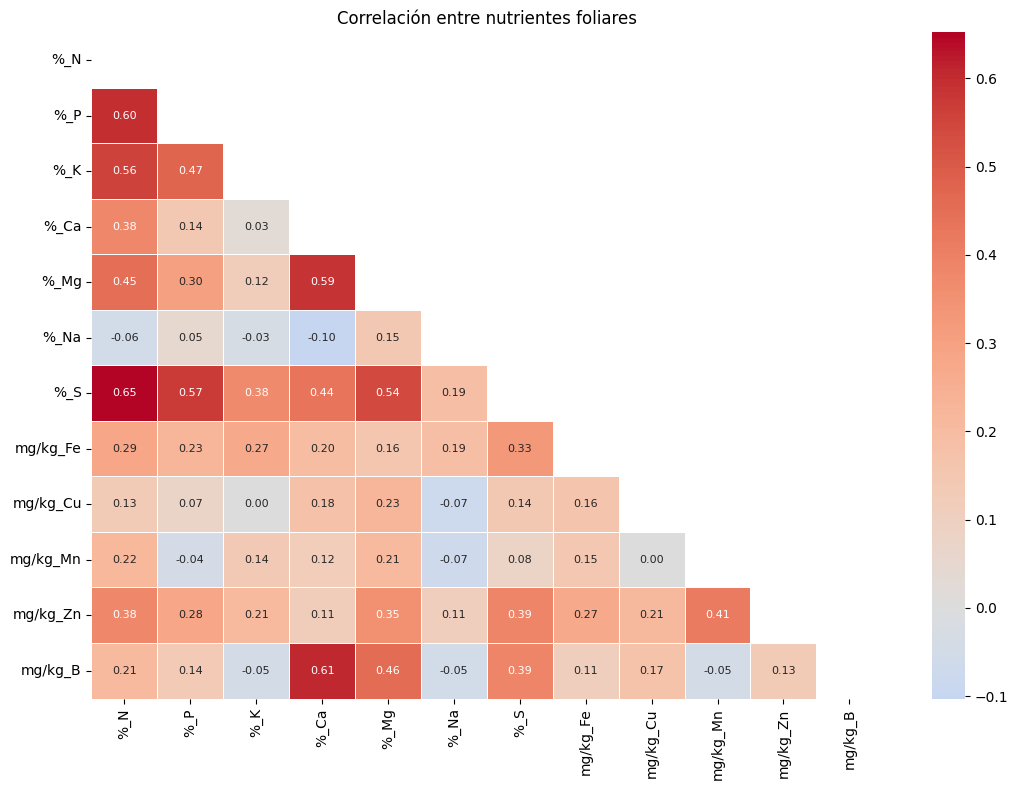

In [ ]:
corr = df_modelo[cols_nutrientes].corr()
plt.figure(figsize=(11,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, mask=mask, annot_kws={'size':8})
plt.title('Correlación entre nutrientes foliares')
plt.tight_layout()
plt.show()

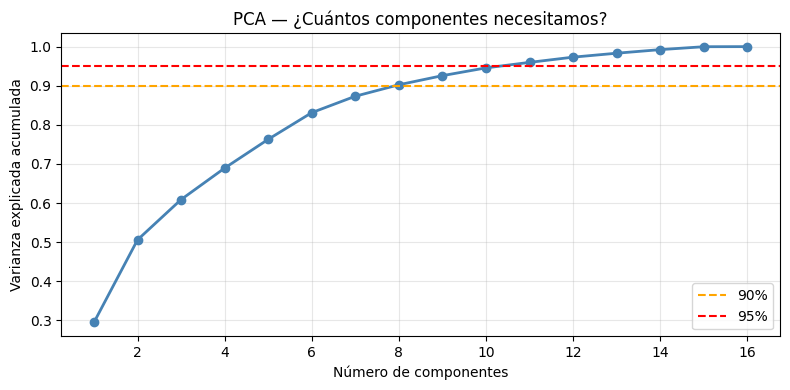

Componentes para 95% de varianza: 11


In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(var_acum)+1), var_acum, marker='o',
         color='steelblue', linewidth=2)
plt.axhline(0.90, color='orange', linestyle='--', label='90%')
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — ¿Cuántos componentes necesitamos?')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_95 = np.argmax(var_acum >= 0.95) + 1
print(f'Componentes para 95% de varianza: {n_95}')

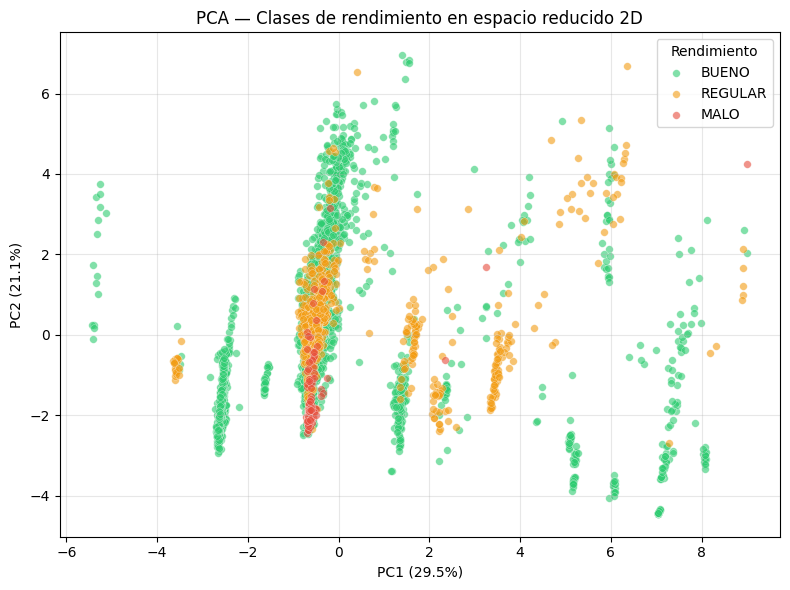

In [ ]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for clase, color in {'BUENO':'#2ecc71','REGULAR':'#f39c12','MALO':'#e74c3c'}.items():
    m = df_modelo['rendimiento'] == clase
    plt.scatter(X_2d[m,0], X_2d[m,1], label=clase, color=color,
                alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Clases de rendimiento en espacio reducido 2D')
plt.legend(title='Rendimiento')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
pca_95 = PCA(n_components=0.95, svd_solver='full')
X_pca = pca_95.fit_transform(X_scaled)
print(f'Dimensiones: {X_scaled.shape[1]} → {X_pca.shape[1]} componentes')

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['rendimiento_cod'] = y.values

X_mod = df_pca.drop(columns=['rendimiento_cod'])
y_mod = df_pca['rendimiento_cod']

X_train, X_test, y_train, y_test = train_test_split(
    X_mod, y_mod, test_size=0.2, random_state=42, stratify=y_mod
)

print(f'Entrenamiento: {X_train.shape}')
print(f'Prueba:        {X_test.shape}')

Dimensiones: 16 → 11 componentes
Entrenamiento: (2728, 11)
Prueba:        (682, 11)


### Interpretación — Selección y extracción de características (PCA)

**Correlación entre nutrientes:**
Las correlaciones más altas se observan entre %_N y %_S (0.65),
%_Ca y mg/kg_B (0.61), y %_Ca y %_Mg (0.59). Ningún par supera
0.85, por lo que se conservan los 12 nutrientes sin eliminar
ninguno.

**Varianza explicada — PCA:**
Se necesitan 11 componentes para explicar el 95% de la varianza
total del dataset, lo que indica que la información está
distribuida entre múltiples dimensiones sin una variable
claramente dominante.

**Scatter 2D:**
PC1 (29.5%) y PC2 (21.1%) explican el 50.6% de la varianza
conjuntamente. La estructura en columnas refleja los diferentes
tipos de cultivo. Las clases BUENO, REGULAR y MALO se solapan
dentro de cada agrupación, lo que indica que el rendimiento
no depende de un solo factor sino de la combinación de
nutrientes y variables agronómicas. La clase MALO aparece
dispersa sin patrón claro, anticipando la dificultad de
los modelos para detectarla.

## 12. Modelos supervisados con class_weight (Sesiones 07, 09, 10, 11)

`class_weight='balanced'` penaliza más los errores en clases minoritarias (MALO, REGULAR) sin eliminar datos. Usamos **F1-score** como métrica principal.

Entrenando Regresión Logística...


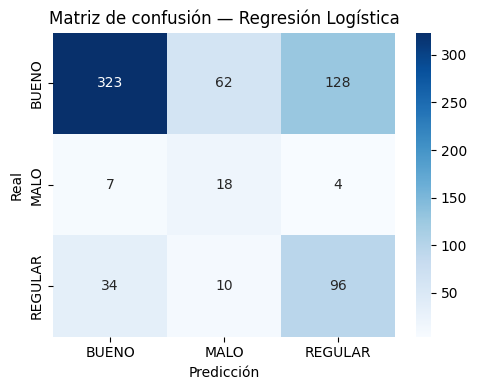

Entrenando Árbol de Decisión...


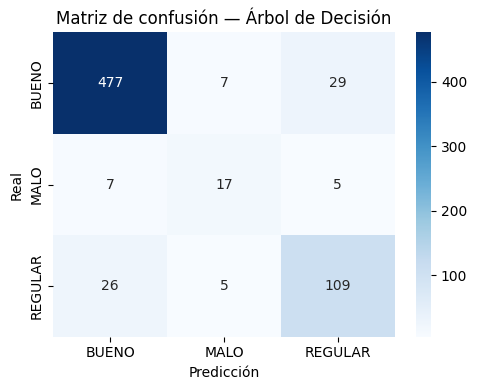

Entrenando Random Forest...


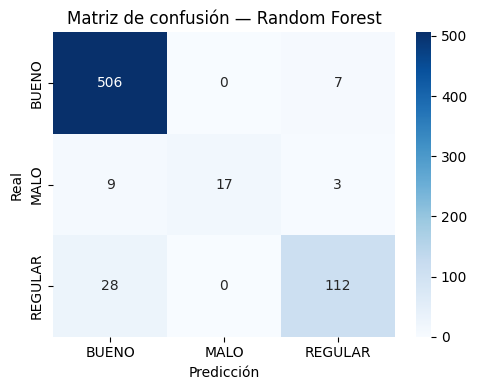

Entrenando KNN...


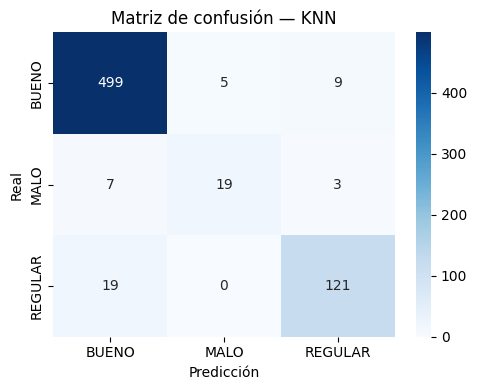

Entrenando SVM (RBF)...


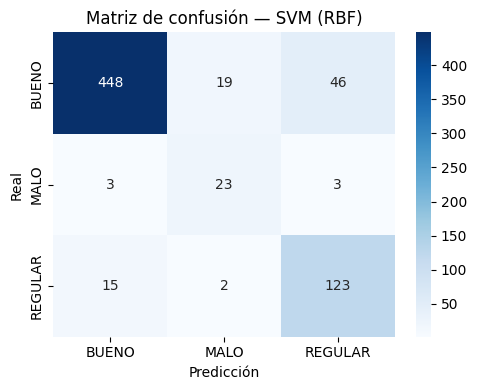

\ Evaluación inicial completada


In [ ]:
modelos = {
    'Regresión Logística' : LogisticRegression(max_iter=1000, random_state=42,
                                                class_weight='balanced'),
    'Árbol de Decisión'   : DecisionTreeClassifier(random_state=42,
                                                    class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42,
                                                    class_weight='balanced'),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'           : SVC(kernel='rbf', C=1, gamma='scale',
                                random_state=42, class_weight='balanced'),
}

resultados = []

for nombre, modelo in modelos.items():
    print(f'Entrenando {nombre}...')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    resultados.append({'Modelo':nombre, 'Accuracy':round(acc,4), 'F1-score':round(f1,4)})
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_rend.classes_, yticklabels=le_rend.classes_)
    plt.title(f'Matriz de confusión — {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

print('\ Evaluación inicial completada')

In [ ]:
df_res = pd.DataFrame(resultados).sort_values('F1-score', ascending=False).reset_index(drop=True)
print('📊 Resultados iniciales:')
display(df_res)

mejor = df_res.iloc[0]['Modelo']
print(f'\n📋 Reporte detallado — {mejor}:')
print(classification_report(y_test, modelos[mejor].predict(X_test),
                             target_names=le_rend.classes_))

📊 Resultados iniciales:


,Modelo,Accuracy,F1-score
0,KNN,0.9370,0.9357
1,Random Forest,0.9311,0.9278
2,Árbol de Decisión,0.8842,0.8845
3,SVM (RBF),0.8710,0.8771
4,Regresión Logística,0.6408,0.6740



📋 Reporte detallado — KNN:
              precision    recall  f1-score   support

       BUENO       0.95      0.97      0.96       513
        MALO       0.79      0.66      0.72        29
     REGULAR       0.91      0.86      0.89       140

    accuracy                           0.94       682
   macro avg       0.88      0.83      0.85       682
weighted avg       0.94      0.94      0.94       682



In [ ]:
# Comparar train vs test para detectar sobreajuste
for nombre, modelo in modelos.items():
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    f1_test  = f1_score(y_test, y_pred_test, average='weighted')
    diff = f1_train - f1_test
    print(f'{nombre:<22} Train: {f1_train:.4f}  Test: {f1_test:.4f}  Diff: {diff:.4f}')

Regresión Logística    Train: 0.7048  Test: 0.6740  Diff: 0.0308
Árbol de Decisión      Train: 1.0000  Test: 0.8845  Diff: 0.1155
Random Forest          Train: 1.0000  Test: 0.9278  Diff: 0.0722
KNN                    Train: 0.9545  Test: 0.9357  Diff: 0.0189
SVM (RBF)              Train: 0.9001  Test: 0.8771  Diff: 0.0231


### Interpretación — Resultados iniciales de modelos supervisados

**Tabla comparativa (ordenada por F1-score):**


Modelo	Accuracy	F1-score
0	KNN	0.9370	0.9357
1	Random Forest	0.9311	0.9278
2	Árbol de Decisión	0.8842	0.8845
3	SVM (RBF)	0.8710	0.8771
4	Regresión Logística	0.6408	0.6740


**KNN es el mejor modelo inicial** con F1-score de 0.9357,
seguido muy de cerca por Random Forest (0.9278) pero este tiene sobreajuste

**Reporte detallado KNN:**
- BUENO: precision=0.95, recall=0.97, F1=0.96 ✅
- MALO: precision=0.79, recall=0.66, F1=0.72 — detecta
  el 66% de los cultivos con mal rendimiento
- REGULAR: precision=0.91, recall=0.86, F1=0.89 ✅


La Regresión Logística es el modelo más débil (F1=0.67),
lo que confirma que las relaciones entre nutrientes y
rendimiento son no lineales — los modelos más complejos
como KNN y Random Forest capturan mejor esos patrones.

## 13. Optimización de hiperparámetros — GridSearchCV

Buscamos los mejores parámetros para cada modelo con validación cruzada de 5 folds.

In [ ]:
param_grids = {
    'Regresión Logística': {'C':[0.01,0.1,1,10,100],
                             'solver':['liblinear','lbfgs']},
    'Árbol de Decisión'  : {'max_depth':[3,5,10,15,None],
                             'min_samples_split':[2,5,10,20]},
    'Random Forest'      : {'n_estimators':[100,200],
                             'max_depth':[5,10,20,None]},
    'KNN'                : {'n_neighbors':[3,5,7,11],
                             'weights':['uniform','distance']},
    'SVM (RBF)'          : {'C':[0.1,1,10],
                             'gamma':['scale','auto']},
}

for nombre, modelo in modelos.items():
    print(f'Optimizando {nombre}...')
    gs = GridSearchCV(estimator=modelo, param_grid=param_grids[nombre],
                      cv=5, scoring='f1_weighted', n_jobs=-1)
    gs.fit(X_train, y_train)
    print(f'  Mejores parámetros: {gs.best_params_}')
    print(f'  Mejor F1 en CV:     {gs.best_score_:.4f}\n')
    modelos[nombre] = gs.best_estimator_

print('Optimización completada')

Optimizando Regresión Logística...
  Mejores parámetros: {'C': 0.1, 'solver': 'liblinear'}
  Mejor F1 en CV:     0.7822

Optimizando Árbol de Decisión...
  Mejores parámetros: {'max_depth': 15, 'min_samples_split': 2}
  Mejor F1 en CV:     0.8873

Optimizando Random Forest...
  Mejores parámetros: {'max_depth': 10, 'n_estimators': 100}
  Mejor F1 en CV:     0.9255

Optimizando KNN...
  Mejores parámetros: {'n_neighbors': 3, 'weights': 'distance'}
  Mejor F1 en CV:     0.9412

Optimizando SVM (RBF)...
  Mejores parámetros: {'C': 10, 'gamma': 'auto'}
  Mejor F1 en CV:     0.9152

Optimización completada


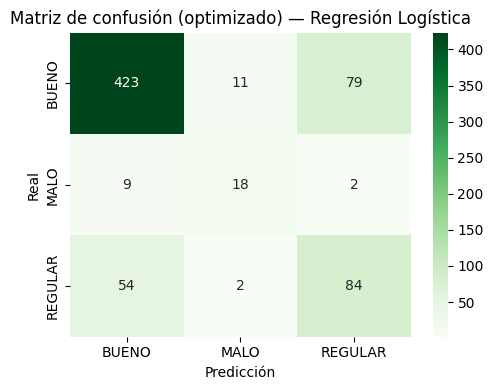

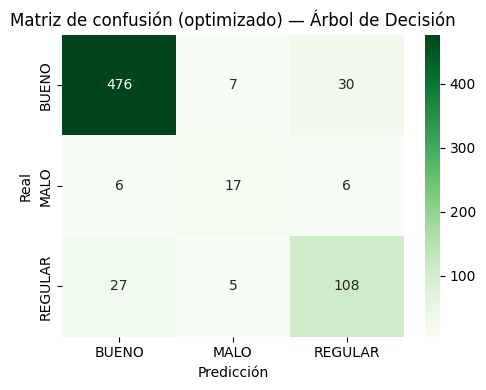

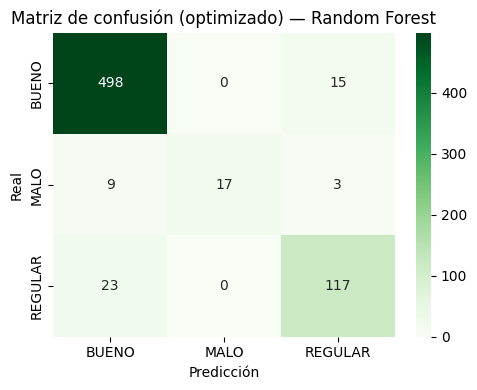

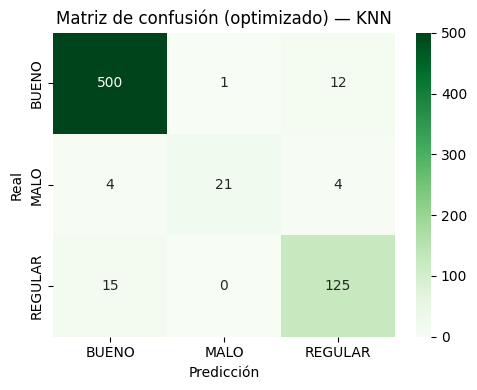

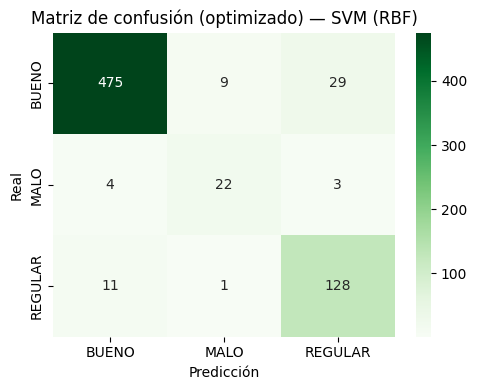

,Modelo,Accuracy,F1-score
0,KNN,0.9472,0.9465
1,Random Forest,0.9267,0.9244
2,SVM (RBF),0.9164,0.9183
3,Árbol de Decisión,0.8812,0.8817
4,Regresión Logística,0.7698,0.7756



📋 Reporte — KNN optimizado:
              precision    recall  f1-score   support

       BUENO       0.96      0.97      0.97       513
        MALO       0.95      0.72      0.82        29
     REGULAR       0.89      0.89      0.89       140

    accuracy                           0.95       682
   macro avg       0.93      0.86      0.89       682
weighted avg       0.95      0.95      0.95       682



In [ ]:
resultados_opt = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    resultados_opt.append({'Modelo':nombre,
                           'Accuracy':round(acc,4),
                           'F1-score':round(f1,4)})
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=le_rend.classes_,
                yticklabels=le_rend.classes_)
    plt.title(f'Matriz de confusión (optimizado) — {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

df_opt = pd.DataFrame(resultados_opt).sort_values(
    'F1-score', ascending=False).reset_index(drop=True)
display(df_opt)

mejor_opt = df_opt.iloc[0]['Modelo']
print(f'\n📋 Reporte — {mejor_opt} optimizado:')
print(classification_report(y_test, modelos[mejor_opt].predict(X_test),
                             target_names=le_rend.classes_))

In [ ]:
print('Verificación sobreajuste post-GridSearchCV:')
print(f'{"Modelo":<22} {"Train":>8} {"Test":>8} {"Diff":>8}')
print('-' * 50)
for nombre, modelo in modelos.items():
    f1_train = f1_score(y_train, modelo.predict(X_train), average='weighted')
    f1_test  = f1_score(y_test, modelo.predict(X_test), average='weighted')
    diff = f1_train - f1_test
    estado = '⚠️' if diff > 0.10 else '✅'
    print(f'{nombre:<22} {f1_train:>8.4f} {f1_test:>8.4f} {diff:>8.4f} {estado}')

Verificación sobreajuste post-GridSearchCV:
Modelo                    Train     Test     Diff
--------------------------------------------------
Regresión Logística      0.7855   0.7756   0.0099 ✅
Árbol de Decisión        0.9949   0.8817   0.1132 ⚠️
Random Forest            0.9909   0.9244   0.0665 ✅
KNN                      1.0000   0.9465   0.0535 ✅
SVM (RBF)                0.9565   0.9183   0.0382 ✅


### Verificación de sobreajuste post-GridSearchCV

Tras la optimización, la mayoría de modelos muestran
diferencias Train-Test por debajo de 0.07, indicando
buena capacidad de generalización.

El Árbol de Decisión sigue con sobreajuste leve (0.1132)
— incluso con max_depth optimizado tiende a memorizar
los datos de entrenamiento.

KNN logra Train=1.0000 en entrenamiento pero Test=0.9465,
con una diferencia de 0.0535 — aceptable y esperado para
KNN que predice perfectamente sus propios datos de entrenamiento.

Random Forest mejoró su sobreajuste de 0.0722 a 0.0665
con la regularización de max_depth.

La Regresión Logística es el modelo más estable
(diff=0.0099) pero también el menos preciso.

## 14. Ensamble — VotingClassifier (Sesión 11)

Combinamos los 5 modelos por votación mayoritaria. Si cada modelo comete errores distintos, el ensamble los compensa.

✓ Accuracy ensamble: 0.9311
✓ F1-score ensamble: 0.9298


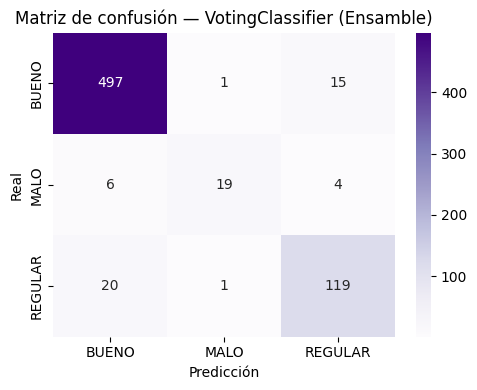

              precision    recall  f1-score   support

       BUENO       0.95      0.97      0.96       513
        MALO       0.90      0.66      0.76        29
     REGULAR       0.86      0.85      0.86       140

    accuracy                           0.93       682
   macro avg       0.91      0.82      0.86       682
weighted avg       0.93      0.93      0.93       682



In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  modelos['Regresión Logística']),
        ('dt',  modelos['Árbol de Decisión']),
        ('rf',  modelos['Random Forest']),
        ('knn', modelos['KNN']),
        ('svm', modelos['SVM (RBF)']),
    ], voting='hard'
)

voting_clf.fit(X_train, y_train)
y_pred_vot = voting_clf.predict(X_test)

acc_vot = accuracy_score(y_test, y_pred_vot)
f1_vot  = f1_score(y_test, y_pred_vot, average='weighted')
print(f'✓ Accuracy ensamble: {acc_vot:.4f}')
print(f'✓ F1-score ensamble: {f1_vot:.4f}')

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_vot), annot=True, fmt='d',
            cmap='Purples', xticklabels=le_rend.classes_,
            yticklabels=le_rend.classes_)
plt.title('Matriz de confusión — VotingClassifier (Ensamble)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_vot, target_names=le_rend.classes_))

,Modelo,Accuracy,F1-score
0,KNN,0.9472,0.9465
1,VotingClassifier,0.9311,0.9298
2,Random Forest,0.9267,0.9244
3,SVM (RBF),0.9164,0.9183
4,Árbol de Decisión,0.8812,0.8817
5,Regresión Logística,0.7698,0.7756


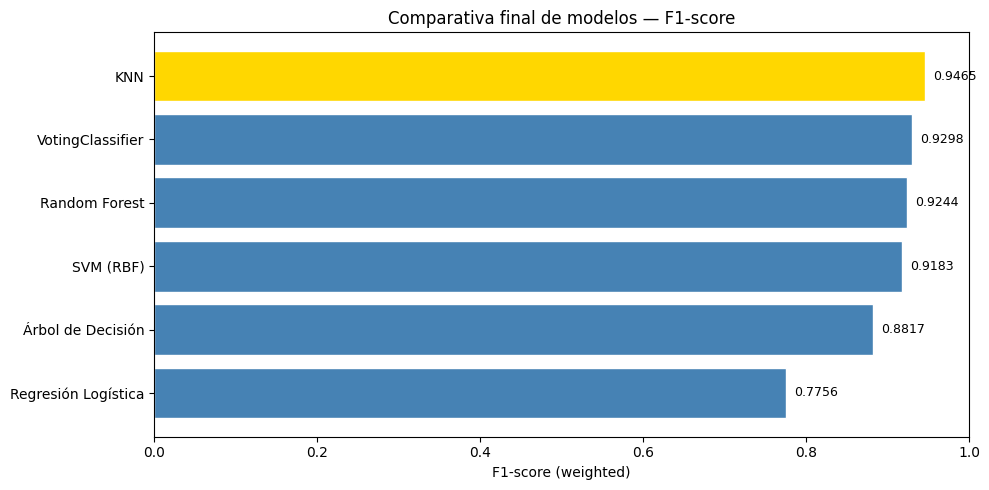

In [ ]:
ensamble_row = pd.DataFrame([{
    'Modelo':'VotingClassifier',
    'Accuracy':round(acc_vot,4),
    'F1-score':round(f1_vot,4)
}])

df_final = pd.concat([df_opt, ensamble_row], ignore_index=True)
df_final = df_final.sort_values('F1-score', ascending=False).reset_index(drop=True)
display(df_final)

plt.figure(figsize=(10,5))
colores_bar = ['gold' if i==0 else 'steelblue' for i in range(len(df_final))]
plt.barh(df_final['Modelo'], df_final['F1-score'],
         color=colores_bar, edgecolor='white')
plt.xlabel('F1-score (weighted)')
plt.title('Comparativa final de modelos — F1-score')
plt.xlim(0,1)
for i, v in enumerate(df_final['F1-score']):
    plt.text(v+0.01, i, str(v), va='center', fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 15. Importancia de variables — ¿Qué predice mejor el rendimiento?

El Random Forest calcula qué variable importa más. Esto responde si son más importantes los nutrientes o las variables agronómicas.

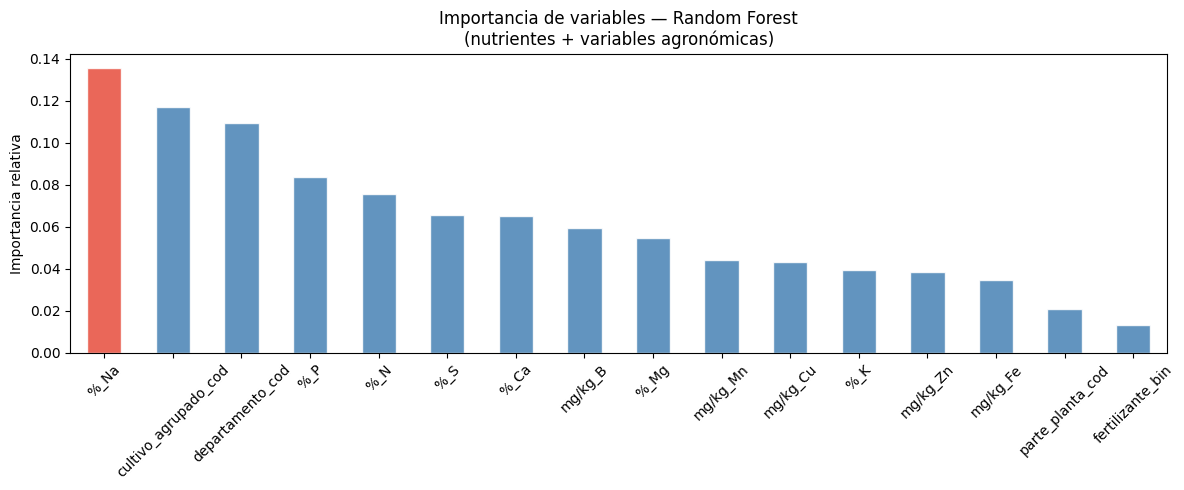

📊 Ranking completo:
   1. %_Na                      ████████████████████ 0.1356
   2. cultivo_agrupado_cod      █████████████████ 0.1172
   3. departamento_cod          ████████████████ 0.1093
   4. %_P                       ████████████ 0.0838
   5. %_N                       ███████████ 0.0756
   6. %_S                       █████████ 0.0656
   7. %_Ca                      █████████ 0.0651
   8. mg/kg_B                   ████████ 0.0595
   9. %_Mg                      ████████ 0.0545
  10. mg/kg_Mn                  ██████ 0.0442
  11. mg/kg_Cu                  ██████ 0.0433
  12. %_K                       █████ 0.0393
  13. mg/kg_Zn                  █████ 0.0383
  14. mg/kg_Fe                  █████ 0.0347
  15. parte_planta_cod          ███ 0.0210
  16. fertilizante_bin          █ 0.0130


In [ ]:
# Feature importance — Random Forest sobre variables originales (sin PCA)
# Entrenamos RF directamente sobre X_scaled para ver nombre real de cada variable

rf_imp = RandomForestClassifier(n_estimators=200, random_state=42,
                                 class_weight='balanced')
rf_imp.fit(X_scaled, y)

importancias = pd.Series(rf_imp.feature_importances_, index=cols_modelo)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(12,5))
colores_imp = ['#e74c3c' if i==0 else 'steelblue' for i in range(len(importancias))]
importancias.plot(kind='bar', color=colores_imp, alpha=0.85, edgecolor='white')
plt.title('Importancia de variables — Random Forest\n(nutrientes + variables agronómicas)')
plt.ylabel('Importancia relativa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('📊 Ranking completo:')
for i, (var, imp) in enumerate(importancias.items(), 1):
    barra = '█' * int(imp*150)
    print(f'  {i:2}. {var:25} {barra} {imp:.4f}')

## 16. Métodos no supervisados — Clustering (Capítulo 6)

Descubrimos grupos naturales en las muestras foliares sin usar la etiqueta de rendimiento. Aplicamos K-Means, DBScan y Mean-Shift.

In [ ]:
X_cluster = scaler.transform(df_modelo[cols_modelo])
print(f'Dataset para clustering: {X_cluster.shape}')

Dataset para clustering: (3410, 16)


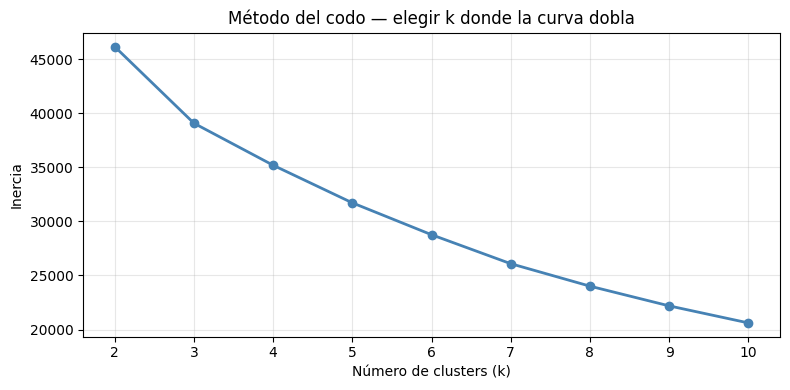

In [ ]:
inercias = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inercias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,11), inercias, marker='o', color='steelblue', linewidth=2)
plt.title('Método del codo — elegir k donde la curva dobla')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


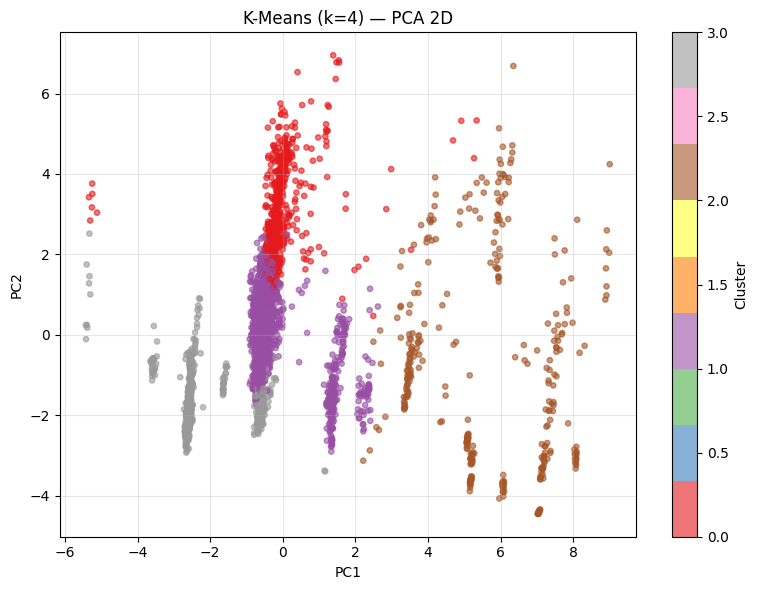

Perfil nutricional promedio por cluster:


,%_N,%_P,%_K,%_Ca,%_Mg,%_Na,%_S,mg/kg_Fe,mg/kg_Cu,mg/kg_Mn,mg/kg_Zn,mg/kg_B
cluster,,,,,,,,,,,,
0,4.129,0.359,3.974,1.639,0.388,0.040,0.358,221.973,8.045,242.443,61.080,43.790
1,2.270,0.194,1.396,1.535,0.342,0.019,0.237,101.982,8.087,207.369,28.747,52.186
2,1.420,0.224,1.589,0.333,0.163,0.067,0.225,249.591,5.655,81.416,27.335,19.715
3,1.256,0.150,1.257,0.263,0.164,0.062,0.107,40.935,5.232,52.962,13.425,16.400


In [ ]:
k_optimo = 4

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_cluster)

pca_vis = PCA(n_components=2)
X_2d_cl = pca_vis.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_2d_cl[:,0], X_2d_cl[:,1],
                      c=labels_km, cmap='Set1', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means (k={k_optimo}) — PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_cluster = df_modelo.copy()
df_cluster['cluster'] = labels_km
print('Perfil nutricional promedio por cluster:')
display(df_cluster.groupby('cluster')[cols_nutrientes].mean().round(3))

DBScan: 3 clusters, 207 outliers


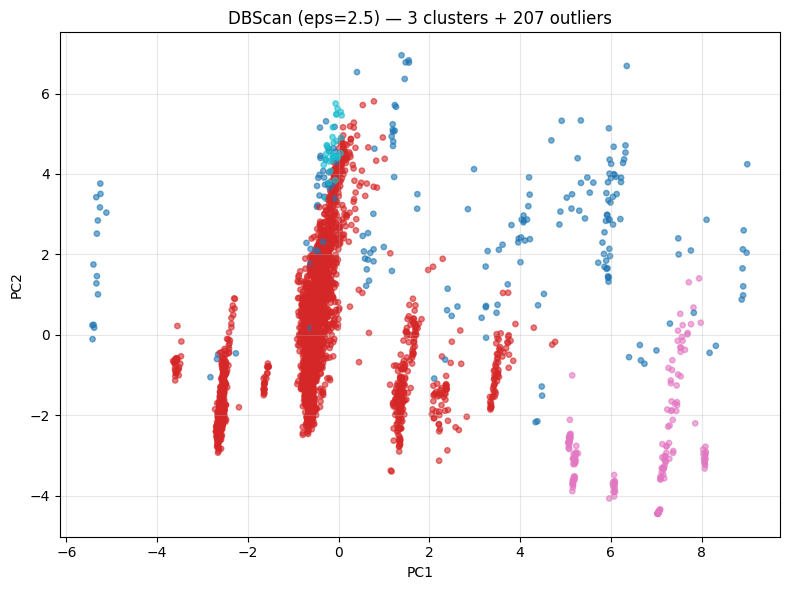

In [ ]:
dbscan = DBSCAN(eps=2.5, min_samples=15)
labels_db = dbscan.fit_predict(X_cluster)
n_cl = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_out = list(labels_db).count(-1)
print(f'DBScan: {n_cl} clusters, {n_out} outliers')

plt.figure(figsize=(8,6))
plt.scatter(X_2d_cl[:,0], X_2d_cl[:,1], c=labels_db,
            cmap='tab10', alpha=0.6, s=15)
plt.title(f'DBScan (eps=2.5) — {n_cl} clusters + {n_out} outliers')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mean-Shift: 3 clusters detectados automáticamente


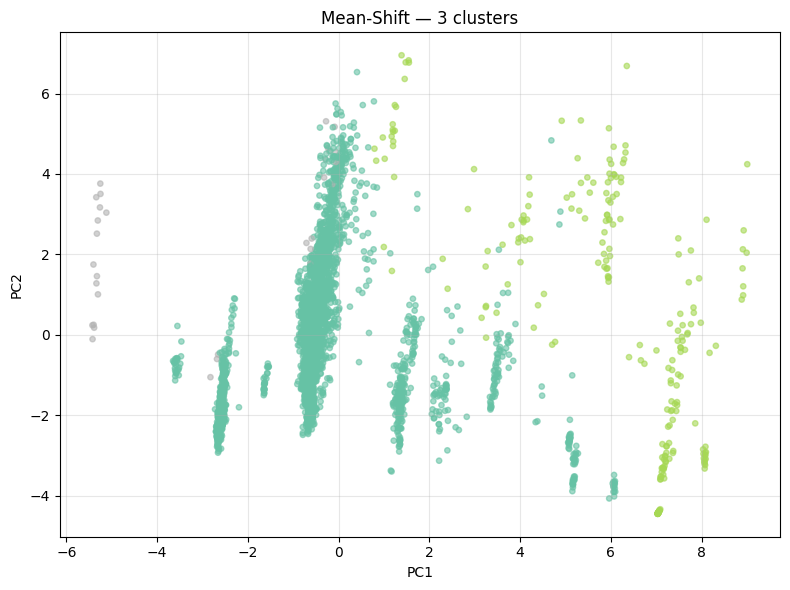

In [ ]:
ms = MeanShift()
labels_ms = ms.fit_predict(X_cluster)
n_ms = len(set(labels_ms))
print(f'Mean-Shift: {n_ms} clusters detectados automáticamente')

plt.figure(figsize=(8,6))
plt.scatter(X_2d_cl[:,0], X_2d_cl[:,1], c=labels_ms,
            cmap='Set2', alpha=0.6, s=15)
plt.title(f'Mean-Shift — {n_ms} clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

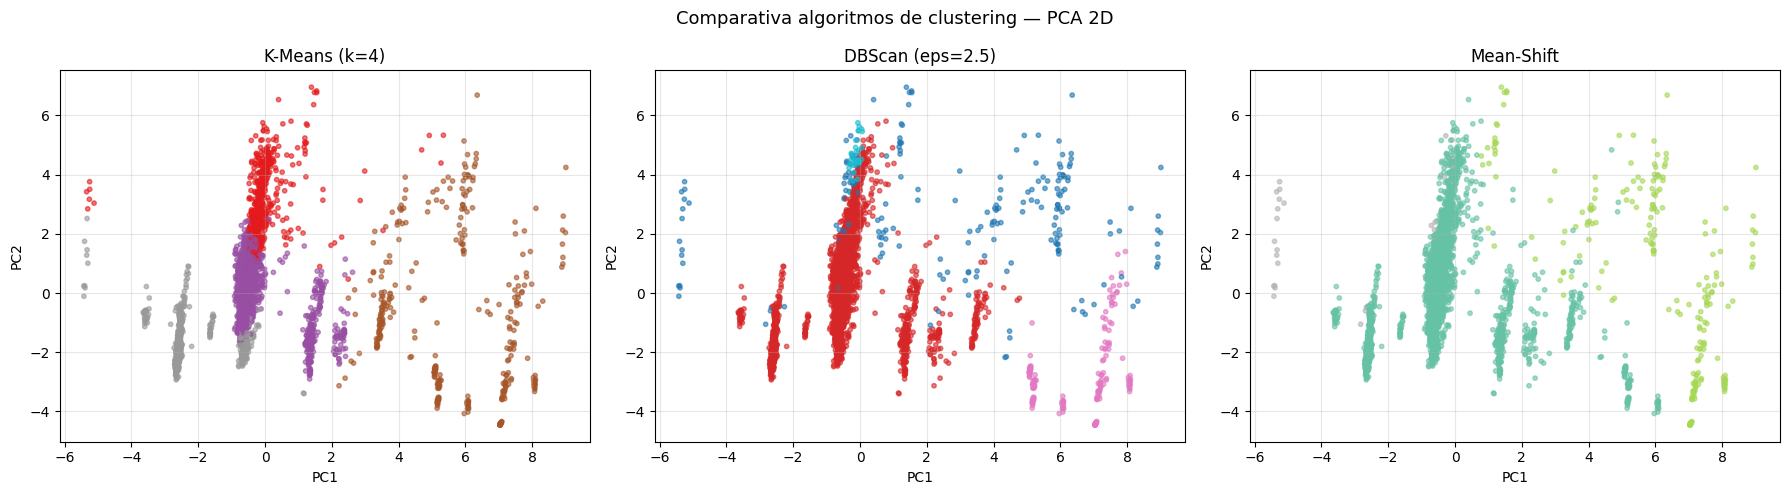

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax, labels, titulo, cmap in zip(
    axes,
    [labels_km, labels_db, labels_ms],
    [f'K-Means (k={k_optimo})', 'DBScan (eps=2.5)', 'Mean-Shift'],
    ['Set1','tab10','Set2']
):
    ax.scatter(X_2d_cl[:,0], X_2d_cl[:,1], c=labels,
               cmap=cmap, alpha=0.6, s=10)
    ax.set_title(titulo)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.3)
plt.suptitle('Comparativa algoritmos de clustering — PCA 2D', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretación — Comparativa de algoritmos de clustering

**K-Means (k=4):**
Divide los datos en 4 grupos de tamaño similar forzando
fronteras esféricas. Los clusters se solapan visualmente
en el espacio PCA, lo que indica que no hay separación
clara entre grupos. La estructura en columnas verticales
(correspondiente a diferentes tipos de cultivo) se
distribuye entre los 4 clusters.

**DBScan (eps=2.5):**
Detectó 3 clusters basándose en densidad, identificando
además 207 outliers (puntos dispersos sin color definido).
Es el algoritmo más informativo porque:
- Encuentra clusters de forma irregular sin asumir forma esférica
- Identifica automáticamente muestras atípicas
- Los 3 clusters coinciden con la cantidad de clases
  de rendimiento del dataset

**Mean-Shift:**
Detectó automáticamente clusters sin necesidad de definir k.
Muestra una transición gradual de colores sugiriendo que
los datos forman un continuo sin grupos claramente separados,
lo cual es consistente con el solapamiento observado
en los boxplots y el PCA.

**Conclusión general del clustering:**
Los tres algoritmos confirman que los datos no tienen
grupos naturalmente bien separados — existe un continuo
de perfiles nutricionales sin fronteras claras entre
cultivos de buen y mal rendimiento. Esto es consistente
con los resultados de los modelos supervisados donde
la clase MALO fue la más difícil de detectar.

DBScan es el algoritmo más útil para este dataset porque
identifica las muestras con perfiles nutricionales
atípicos (outliers) que podrían corresponder a cultivos
en condiciones edáficas extremas o errores de muestreo.